# Beyond the Spread: Quantifying the Alignment Gap Between Battery Arbitrage and Energy System Resilience

**Research question.** Grid-scale batteries are dispatched to maximise trading profit.
How much of that profit-optimal behaviour coincides with what a resilient system needs —
discharging when the system is tight, absorbing when it is in surplus — and what does full
alignment cost?

**Data.** The most recent ~60 days of GB market and system data, all public and free:
Nord Pool N2EX day-ahead prices, Elexon MID / FUELHH generation / ITSDO demand,
Sheffield Solar PV_Live embedded solar, and per-BMU Physical Notifications for **every
BM-registered GB battery site** — the 87-site census reconstructed in
notebook 06, not the smaller population the live dashboard renders. No API
keys; every number in this notebook is reproducible from the repository's fetchers.

**Population note.** The census is identified from Elexon's own reference data (see
notebook 06), and its metadata is machine-derived for sites the curated registry does not
cover. Declared MW comes from Elexon and is sound throughout, so everything normalised by
power is comparable across the fleet. Energy capacity is known for only 42 of the 87
sites, so any metric dividing by MWh is reported over that subset and labelled.

**Method.** (i) Settle a reference battery (50 MW / 2h) with the repository's
profit-optimising engine over the window. (ii) Classify every half-hour by system state:
*top-decile load* = top decile of residual load (transmission demand − wind) over the window;
*surplus* = bottom decile or negative prices. (iii) Score the alignment of the
profit-optimal dispatch and of each real site's Physical Notifications with the same
scorer. (iv) Solve a resilience-optimal counterfactual under identical physics and price
the gap between the two dispatches.

**What "stress" means here, and what it does not.** Every stress figure in this notebook
comes from the **top decile of residual load** — transmission demand minus wind. That
is a measure of **system utilisation**: when the fleet is working hardest. It is *not* the
operator's judgement that the system is at risk, and the two are not interchangeable. Notebook
05's overlap table shows the residual decile catches barely half of the periods Elexon flags
with a top-percentile loss-of-load probability, and because residual load has fallen roughly
30% across 2018–2026 as wind capacity grew, a decile taken over a long window lands
disproportionately on its early years.

Every printed label and figure below therefore says **top-decile**, not stress. The *code*
still calls the flag `stress` — `live.resilience.classify_periods` returns that column and the
dashboard, the settlement engine and six test files read it, so renaming an internal key would
risk all of that and buy nothing. A variable name is a handle; a printed label is a claim, and
only the claim needed fixing. For scarcity as the operator defines it —
`LoLP >= 1e-4`, de-rated margin under 1 GW, a Capacity Market Notice issued — see notebooks 05,
07 and 08, which condition on those directly. The choice here is deliberate rather than
careless: this notebook prices a *counterfactual dispatch* over a 60-day window, and operator
scarcity is far too rare in 60 days to optimise against. Utilisation is the right conditioning
signal for the question this notebook asks; it is the wrong word for it, and the word is what
this paragraph fixes.

**Engine caveat, stated up front.** The benchmark settles with perfect-foresight intraday
against realised MID — an upper bound on price-responsiveness. Alignment measured on this
dispatch is therefore the *most* price-responsive case; a real trader tracks it from
below. Sections 1-5 price wholesale + BM only and flag low-cycling ancillary-tilted sites;
section 5b adds per-unit response and reserve revenue from NESO's auction results and
re-tests the headline relationship on the full stack.

In [1]:
import json
%matplotlib inline

import datetime as dt
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from research.notebooks.figexport import save_poster_fig

from live import classify, fetch_live, resilience, settle
from live.assets import bess_config, build_assets
from fleet import fetch_fleet
from fleet.research import ancillary, census
from fleet import performance as fleet_perf
from fleet.population import census_population
from src.bess.bess_asset import BESSAsset

# ── Frozen vintage ──────────────────────────────────────────────────────────
# The registers behind the census and NESO's auction results are both live, so
# an unpinned run returns a different population and different revenue every
# day, and every number below moves with it. This notebook fixes both at
# 2026-08-24 — the same date notebooks 04, 05 and 06 all use, so the three are
# directly comparable. The library default is unpinned; this is a notebook
# decision, set here rather than in the repo.
#
# To move the analysis on: change this date, re-run, and update any figure of
# this notebook's that README.md, DATA_ARCHITECTURE.md or the poster quote.
census.SNAPSHOT = dt.date(2026, 8, 24)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Consistent hexes with the dashboard's design system.
C = {
    "ink":       "#0b0b0b",
    "da":        "#2a78d6",
    "discharge": "#1baf7a",
    "charge":    "#eb6834",
    "cost":      "#e34948",
    "mid":       "#c98500",
    "ghost":     "#c3c2b7",
    "stress":    (0.89, 0.29, 0.28, 0.14),
    "surplus":   (0.11, 0.69, 0.48, 0.12),
}


# The fleet studied here is the full BM-registered census, not the smaller
# population the live dashboard renders — that one keeps only sites whose energy
# capacity is published and which cycle enough to price, both of which this
# notebook has no reason to require. `fleet.registry` states its size. Using the
# whole census is what makes "the fleet discharges into stress" a statement
# about GB rather than about a sample.
# Every fleet call below passes POP explicitly — nothing relies on the default.
POP = census_population()

# Reference asset: 50 MW / 2h (the modal new-build GB configuration), engine
# levers at production config values.
DURATION = "2h"
POWER_MW = 50.0
CFG = bess_config()
WINDOW_DAYS = 60

# The window is pinned, not rolling. Nord Pool publishes GB day-ahead prices on
# a rolling ~60-day basis, so a window defined relative to "today" moves every
# time the notebook runs and every headline number moves with it — which is
# untenable for a printed poster. These dates sit inside the cached price
# archive, so the run is reproducible from disk with no network call. Move
# WINDOW_END forward deliberately, and re-cache prices first.
WINDOW_END = dt.date(2026, 8, 24)
DATES = [WINDOW_END - dt.timedelta(days=i) for i in range(WINDOW_DAYS - 1, -1, -1)]
print(f"Window (pinned)  : {DATES[0]} → {DATES[-1]}  ({WINDOW_DAYS} days)")
print(f"Fleet population : {len(POP)} sites, {len(POP.bmu_ids())} BM Units "
      f"({sum(s.power_mw for s in POP.sites):,.0f} MW declared)")
print(f"Asset            : {POWER_MW:.0f} MW × {DURATION} | cycle cap "
      f"{CFG.get('target_daily_cycles')} | slippage "
      f"£{CFG.get('execution', {}).get('slippage')}/MWh")

No event loop hook running.
Window (pinned)  : 2026-06-26 → 2026-08-24  (60 days)
Fleet population : 87 sites, 124 BM Units (6,234 MW declared)
Asset            : 50 MW × 2h | cycle cap 1.5 | slippage £2.0/MWh


Worksheet row for GB-BESS-WOLVB (Wolverhampton West BESS) needs review: 310 MWh over 56.0 MW declared implies 5.5 h, longer than any priced census site. Self-consistent with the duration recorded, so the agreement check cannot judge it — confirm the figure covers this BM Unit and not the wider project.


## 1. Settle the profit-optimal benchmark over the window

One asset, SOC carried day to day. Days whose price data is unavailable (Nord Pool serves
roughly the last 65 days) drop out of the window; every retained day settles with the
same engine the live dashboard runs.


In [2]:
assets = {DURATION: build_assets()[DURATION]}
prev = {DURATION: assets[DURATION].initial_soc_pct}
records = []
for date in DATES:
    try:
        prices = fetch_live.get_day_prices(date)
    except Exception:
        continue
    result = settle.settle_day(date, prices, CFG, assets, prev)
    if result is None:
        continue
    prev = {d: r.end_soc for d, r in result.durations.items()}
    try:
        context = fetch_live.get_day_context(date)
    except Exception:
        context = {}
    records.append({
        "date": date,
        "result": result.durations[DURATION],
        "labels": classify.classify(prices, context),
        "da_prices": prices["day_ahead_price"].tolist(),
    })

DATES_OK = [r["date"] for r in records]
net = pd.Series([r["result"].net_pnl for r in records], index=pd.to_datetime(DATES_OK))
print(f"Settled days     : {len(records)}  ({DATES_OK[0]} → {DATES_OK[-1]})")
print(f"Benchmark        : £{net.mean() / POWER_MW:,.0f}/MW/day mean · "
      f"£{net.sum():,.0f} total")

Settled days     : 60  (2026-06-26 → 2026-08-24)
Benchmark        : £106/MW/day mean · £318,776 total


## 2. Classify the system: stress and surplus

Residual load is what the rest of the fleet must serve after wind and embedded solar.
Thresholds are quantiles over the shown window, so "stress" means stressed relative to
this period — no external scarcity data enters. The hour-of-day distribution below is
context for every later figure: GB stress in this window is an evening phenomenon,
surplus a midday one.


Classified       : 2,880 half-hours over 60 days
Top-decile periods: 288 (threshold 24.8 GW)
Surplus periods  : 288 (incl. 28 negative-price)


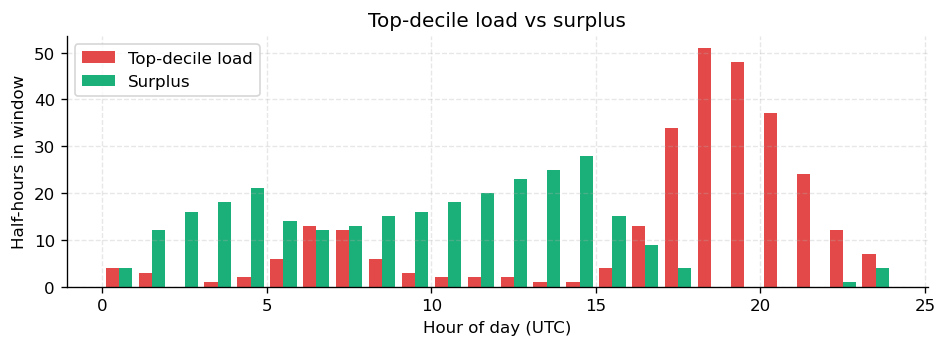

In [3]:
residual_parts, price_parts = [], []
for r in records:
    system = fetch_live.get_day_system(r["date"])
    if system.empty:
        continue
    residual_parts.append(resilience.residual_load(system))
    idx = pd.date_range(str(r["date"]), periods=len(r["da_prices"]), freq="1h", tz="UTC")
    price_parts.append(pd.Series(r["da_prices"], index=idx))

residual = pd.concat(residual_parts).sort_index()
da_series = pd.concat(price_parts).sort_index()
flags = resilience.classify_periods(residual, da_series)

hourly_flags = pd.DataFrame({
    "residual_mw": flags["residual_mw"].resample("1h").mean(),
    "stress": flags["stress"].resample("1h").max().astype(bool),
    "surplus": flags["surplus"].resample("1h").max().astype(bool),
}).dropna(subset=["residual_mw"])

print(f"Classified       : {len(flags):,} half-hours over {len(residual_parts)} days")
print(f"Top-decile periods: {int(flags['stress'].sum())} "
      f"(threshold {flags['residual_mw'].quantile(resilience.STRESS_QUANTILE)/1000:,.1f} GW)")
print(f"Surplus periods  : {int(flags['surplus'].sum())} "
      f"(incl. {int((da_series.reindex(flags.index).ffill() < 0).sum())} negative-price)")

fig, ax = plt.subplots(figsize=(8, 3))
top_decile_hours = flags[flags["stress"]].index.hour
surplus_hours = flags[flags["surplus"]].index.hour
ax.hist([top_decile_hours, surplus_hours], bins=range(25),
        label=["Top-decile load", "Surplus"], color=[C["cost"], C["discharge"]])
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Half-hours in window")
ax.set_title("Top-decile load vs surplus")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Alignment of the profit-optimal dispatch

Three statistics, all computed from the settled dispatch and the classification above:
top-decile coverage (share of discharged energy delivered in stress periods), surplus
absorption (share of charged energy drawn in surplus periods), and readiness (mean state
of charge at the onset of each stress block). Figure 1 shows the mechanism on the
highest-stress day of the window.


In [4]:
dispatch_map, soc_map = {}, {}
for r in records:
    log = r["result"].dispatch_log
    idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
    for ts, e in zip(idx, log):
        dispatch_map[ts] = e["final_mw"]
        soc_map[ts] = e["soc_before"]
sim_dispatch = pd.Series(dispatch_map).sort_index()
sim_soc = pd.Series(soc_map).sort_index()

scores = resilience.alignment_scores(sim_dispatch, hourly_flags)
readiness = resilience.readiness_at_stress(sim_soc, hourly_flags["stress"])
print(f"Top-decile coverage: {scores['stress_coverage']:.1%}")
print(f"Surplus absorption : {scores['surplus_absorption']:.1%}")
print(f"Readiness at onset : {readiness:.1%}")
print(f"Dispatch–residual correlation: {scores['correlation']:+.2f}")

# Exported for notebook 09, which overlays this profile on the real fleet's.
# Normalised per MW installed, so a 50 MW model asset and a multi-GW fleet sit
# on one axis; the hour-of-day mean is over the whole pinned window.
_prof = (sim_dispatch / POWER_MW).groupby(sim_dispatch.index.hour).mean()
_prof_path = REPO_ROOT / "research/notebooks/_outputs/nb04_model_profile.json"
_prof_path.parent.mkdir(parents=True, exist_ok=True)
_prof_path.write_text(json.dumps({
    "profit_mw_per_mw": {str(h): round(float(v), 6) for h, v in _prof.items()},
    "power_mw": POWER_MW,
    "window_start": str(DATES[0]),
    "window_end": str(DATES[-1]),
}, indent=2) + "\n")
print(f"Model profile exported   : {_prof_path.name}")

Top-decile coverage: 37.4%
Surplus absorption : 19.9%
Readiness at onset : 72.0%
Dispatch–residual correlation: +0.31
Model profile exported   : nb04_model_profile.json


<ipython-input-5-019afb4f1b38>:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


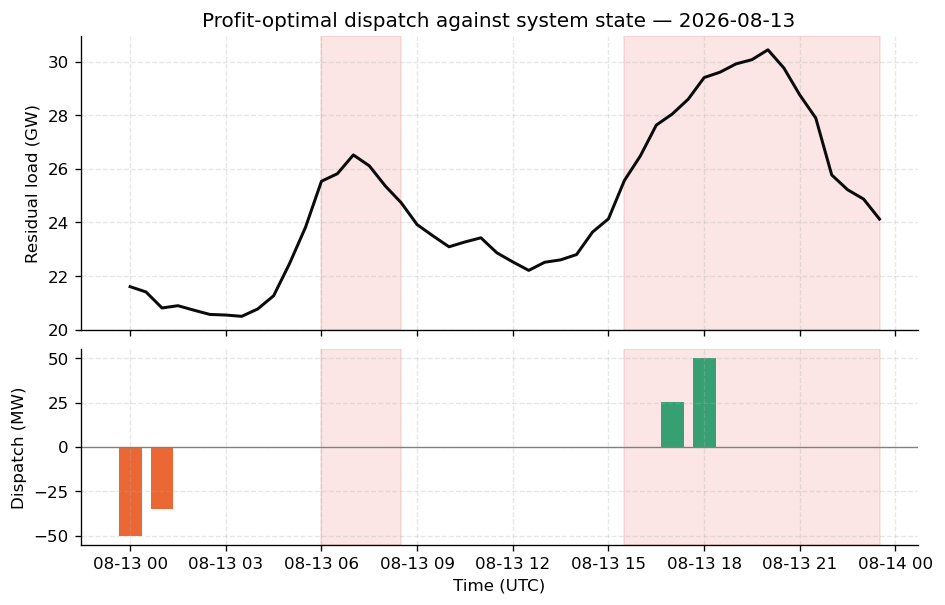

In [5]:
# Figure 1 — exemplar day: the day containing the window's highest residual load.
peak_ts = flags["residual_mw"].idxmax()
day = peak_ts.date()
day_flags = flags[flags.index.date == day]
day_disp = sim_dispatch[sim_dispatch.index.date == day]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
ax1.plot(day_flags.index, day_flags["residual_mw"] / 1000.0, color=C["ink"], lw=1.8)
ax1.set_ylabel("Residual load (GW)")
ax1.set_title(f"Profit-optimal dispatch against system state — {day}")
ax2.bar(day_disp.index, day_disp.values, width=0.03,
        color=[C["discharge"] if v > 0 else C["charge"] for v in day_disp.values])
ax2.axhline(0, color="grey", lw=0.8)
ax2.set_ylabel("Dispatch (MW)")
ax2.set_xlabel("Time (UTC)")
for ax in (ax1, ax2):
    for start, end, flag_col, colour in (
        (None, None, "stress", C["stress"]), (None, None, "surplus", C["surplus"]),
    ):
        in_span = False
        s = None
        series = day_flags[flag_col]
        for ts, val in series.items():
            if val and not in_span:
                s, in_span = ts, True
            elif not val and in_span:
                ax.axvspan(s, ts, color=colour)
                in_span = False
        if in_span:
            ax.axvspan(s, series.index[-1], color=colour)
plt.tight_layout()
# Print-resolution export for the poster: profit-optimal dispatch through a stress day.
save_poster_fig(fig, "nb04_fig1_exemplar_day")

plt.show()

### The systemic view: one day is an anecdote

The exemplar day above shows the mechanism, which is what an exemplar is for. It cannot show
whether the mechanism is *typical*, and a single 24-hour trace is the kind of evidence a
reader is right to discount. The figure below is the same picture averaged over every day in
the window that contains a stress hour, so the shape it shows is the season's rather than one
day's.

It also corrects a plausible guess. One expects a price-following battery to discharge *early*
— chasing the evening price peak and emptying before the system's physical peak. That is not
what happens: mean discharge peaks at the same hour as stress probability. The gap is not in
the timing, it is in the **duration**. The battery enters the window nearly full, spends itself
across the first two hours, and reaches its floor while the system is still tight.

Duration frontier qualification: each duration starts every day at 50% SOC. Inventory resets and additional capacity are unpriced; these are conditional daily comparisons, not continuous strategies or procurement bounds. The duration frontier reports raw DA cash value; other alignment-gap counterfactuals credit terminal inventory at mean DA price.


Discharge peaks at 19:00; system tightest at 18:00.
State of charge first reaches its 10% floor at 21:00, while the system is still tight in 56% of top-decile days at that hour.
Within top-decile hours (n=161): profit-optimal delivers +11.1 MW mean and is discharging in 32% of them;
resilience-optimal +14.9 MW in 39%.


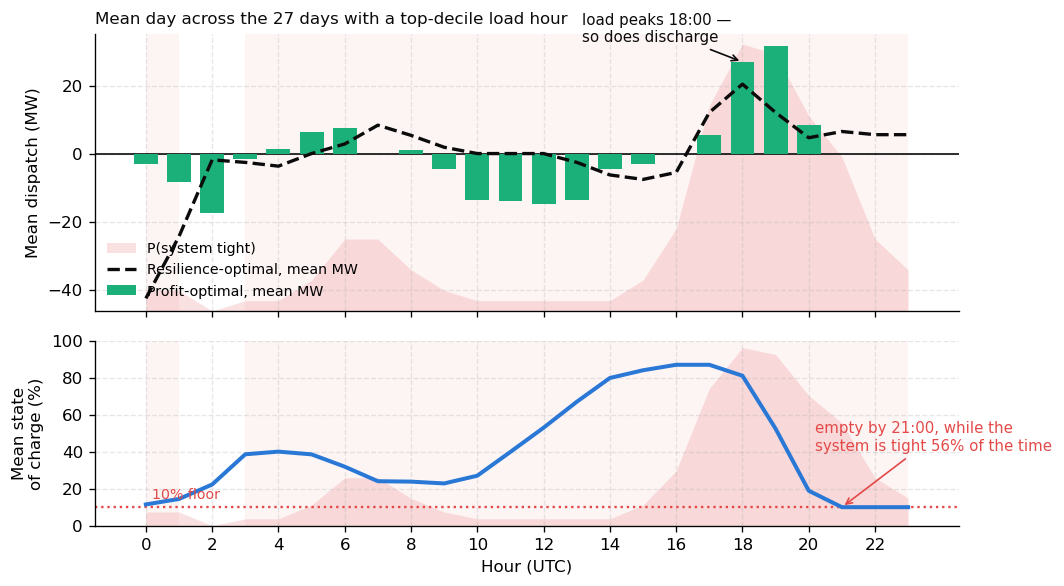

In [6]:
# Figure 2 — the diurnal shape of the mismatch, over every stress day in the window.
rows = []
for r in records:
    log = r["result"].dispatch_log
    idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
    st = hourly_flags["stress"].reindex(idx, fill_value=False)
    su = hourly_flags["surplus"].reindex(idx, fill_value=False)
    # Days with no stress at all would drag the resilience curve toward zero for
    # a reason that has nothing to do with behaviour, so they are excluded.
    if not st.any():
        continue
    asset = BESSAsset(
        capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
        charge_efficiency=CFG["charge_efficiency"],
        discharge_efficiency=CFG["discharge_efficiency"],
        degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
        initial_soc_pct=log[0]["soc_before"] if log else 0.5,
        min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
    )
    res_mw = resilience.optimize_resilience_dispatch(
        st.tolist(), su.tolist(), asset, target_daily_cycles=CFG.get("target_daily_cycles")
    )
    for ts, entry, res_v, stressed in zip(idx, log, res_mw, st.tolist()):
        rows.append({"hour": ts.hour, "profit": entry["final_mw"], "resilience": res_v,
                     "soc": entry["soc_before"], "stress": stressed})

diurnal = pd.DataFrame(rows)
stress_days = len(diurnal) // 24
prof = diurnal.groupby("hour").agg(
    p_stress=("stress", "mean"), profit=("profit", "mean"),
    resilience=("resilience", "mean"), soc=("soc", "mean"),
)

# The three timing figures the poster quotes, printed rather than left to be
# read off the panel. A number that only exists inside a figure cannot be
# checked when the window moves, which is how the old ones went stale.
_peak_h = int(prof["profit"].idxmax())
_floor = CFG["min_soc_pct"]
_at_floor = prof.index[prof["soc"] <= _floor * 1.02]
_floor_h = int(_at_floor.min()) if len(_at_floor) else None
print(f"Discharge peaks at {_peak_h:02d}:00; system tightest at "
      f"{int(prof['p_stress'].idxmax()):02d}:00.")
if _floor_h is not None:
    print(f"State of charge first reaches its {_floor:.0%} floor at {_floor_h:02d}:00, "
          f"while the system is still tight in {prof.loc[_floor_h, 'p_stress']:.0%} "
          f"of top-decile days at that hour.")
else:
    print(f"State of charge never reaches the {_floor:.0%} floor in the mean profile "
          f"(minimum {prof['soc'].min():.0%}).")

fig, axes = plt.subplots(2, 1, figsize=(9, 5.0), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})
x = prof.index.to_numpy()

# The tight-system band sits behind both panels, so dispatch and state of charge
# are read against the same window rather than against each other.
for ax in axes:
    ax.fill_between(x, 0, 1, where=prof["p_stress"] > 0, transform=ax.get_xaxis_transform(),
                    color=C["cost"], alpha=0.06, lw=0, zorder=0)
    ax.fill_between(x, 0, prof["p_stress"], transform=ax.get_xaxis_transform(),
                    color=C["cost"], alpha=0.16, lw=0, zorder=1,
                    label="P(system tight)" if ax is axes[0] else None)

ax = axes[0]
ax.bar(x, prof["profit"], width=0.72, color=C["discharge"], zorder=3,
       label="Profit-optimal, mean MW")
ax.plot(x, prof["resilience"], color=C["ink"], lw=2, ls="--", zorder=4,
        label="Resilience-optimal, mean MW")
ax.axhline(0, color=C["ink"], lw=1, zorder=2)
ax.set_ylabel("Mean dispatch (MW)")
peak = int(prof["p_stress"].idxmax())
ax.annotate(f"load peaks {peak:02d}:00 —\nso does discharge",
            (peak, prof.loc[peak, "profit"]), xytext=(-96, 12),
            textcoords="offset points", fontsize=9, color=C["ink"],
            arrowprops={"arrowstyle": "->", "color": C["ink"], "lw": 1})
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=1)
ax.set_title(f"Mean day across the {stress_days} days with a top-decile load hour",
             fontsize=10, loc="left", color=C["ink"])

ax = axes[1]
ax.plot(x, 100 * prof["soc"], color=C["soc"] if "soc" in C else C["da"], lw=2.4, zorder=3)
floor = 100 * CFG["min_soc_pct"]
ax.axhline(floor, color=C["cost"], ls=":", lw=1.4, zorder=2)
ax.annotate(f"{floor:.0f}% floor", (0.2, floor), xytext=(0, 5),
            textcoords="offset points", fontsize=8.5, color=C["cost"])
empty = prof.index[(100 * prof["soc"] <= floor + 1) & (prof["p_stress"] > 0.2)]
if len(empty):
    h = int(empty[0])
    ax.annotate(f"empty by {h:02d}:00, while the\nsystem is tight {prof.loc[h, 'p_stress']:.0%} of the time",
                (h, floor), xytext=(-16, 34), textcoords="offset points", fontsize=9,
                color=C["cost"], arrowprops={"arrowstyle": "->", "color": C["cost"], "lw": 1})
ax.set_ylabel("Mean state\nof charge (%)")
ax.set_ylim(0, 100)
ax.set_xlabel("Hour (UTC)")
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
# Print-resolution export for the poster: the systemic replacement for the exemplar day.
save_poster_fig(fig, "nb04_fig2_diurnal_mismatch")

plt.show()

served = diurnal[diurnal["stress"]]
print(f"Within top-decile hours (n={len(served)}): profit-optimal delivers "
      f"{served['profit'].mean():+.1f} MW mean and is discharging in "
      f"{(served['profit'] > 0).mean():.0%} of them;\nresilience-optimal "
      f"{served['resilience'].mean():+.1f} MW in {(served['resilience'] > 0).mean():.0%}.")

## 4. The alignment gap

For every day, a resilience-optimal counterfactual is solved under identical physics
(same SOC window, power, efficiency and cycle cap; objective = deliver in stress, absorb
in surplus) starting from the same carried-over SOC. Both schedules are valued at cleared
DA prices with a symmetric terminal-inventory credit (day-end SOC change at the day-mean
price). Two numbers price the trade-off:

* **Cost of full alignment** — DA value the profit-optimal dispatch gives up by switching
  to the resilience-optimal schedule.
* **Stress delivery forgone** — stress-hour energy pure arbitrage leaves undelivered
  relative to the counterfactual.


Cost of full alignment : £39/MW/day (39% of DA value)
Top-decile MWh, arbitrage : 1,930 MWh
Top-decile MWh, system    : 2,399 MWh
Delivery forgone         : 469 MWh (20% of the resilience-optimal delivery)


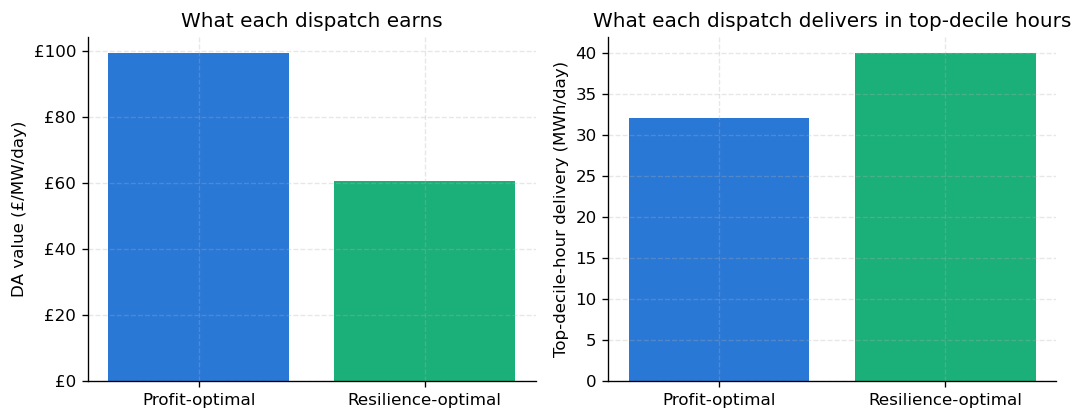

In [7]:
gap_rows = []
for r in records:
    log = r["result"].dispatch_log
    idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
    stress = hourly_flags["stress"].reindex(idx, fill_value=False).tolist()
    surplus = hourly_flags["surplus"].reindex(idx, fill_value=False).tolist()
    asset = BESSAsset(
        capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
        charge_efficiency=CFG["charge_efficiency"],
        discharge_efficiency=CFG["discharge_efficiency"],
        degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
        initial_soc_pct=log[0]["soc_before"] if log else 0.5,
        min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
    )
    gap = resilience.alignment_gap(
        [e["final_mw"] for e in log], r["da_prices"], stress, surplus, asset,
        target_daily_cycles=CFG.get("target_daily_cycles"),
    )
    gap["date"] = r["date"]
    gap["labels"] = r["labels"]
    gap_rows.append(gap)
gap_df = pd.DataFrame(gap_rows)

mean_gap = gap_df["profit_cost_of_alignment"].mean() / POWER_MW
mean_profit = gap_df["profit_arb"].mean() / POWER_MW
print(f"Cost of full alignment : £{mean_gap:,.0f}/MW/day "
      f"({gap_df['profit_cost_of_alignment'].sum() / gap_df['profit_arb'].sum():.0%} "
      f"of DA value)")
print(f"Top-decile MWh, arbitrage : {gap_df['stress_mwh_arb'].sum():,.0f} MWh")
print(f"Top-decile MWh, system    : {gap_df['stress_mwh_res'].sum():,.0f} MWh")
print(f"Delivery forgone         : {gap_df['stress_mwh_forgone'].sum():,.0f} MWh "
      f"({gap_df['stress_mwh_forgone'].sum() / max(gap_df['stress_mwh_res'].sum(), 1e-9):.0%} "
      f"of the resilience-optimal delivery)")

# Figure 2 — the two dispatches on both value axes.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
labels = ["Profit-optimal", "Resilience-optimal"]
profit_vals = [gap_df["profit_arb"].mean() / POWER_MW, gap_df["profit_res"].mean() / POWER_MW]
stress_vals = [gap_df["stress_mwh_arb"].mean(), gap_df["stress_mwh_res"].mean()]
ax1.bar(labels, profit_vals, color=[C["da"], C["discharge"]])
ax1.set_ylabel("DA value (£/MW/day)")
ax1.set_title("What each dispatch earns")
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
ax2.bar(labels, stress_vals, color=[C["da"], C["discharge"]])
ax2.set_ylabel("Top-decile-hour delivery (MWh/day)")
ax2.set_title("What each dispatch delivers in top-decile hours")
plt.tight_layout()
# Print-resolution export for the poster: value earned against stress energy delivered.
save_poster_fig(fig, "nb04_fig2_value_vs_stress_energy")

plt.show()

In [8]:
# The alignment frontier — the whole trade-off, not its two endpoints.
#
# Comparing profit-optimal against fully resilience-optimal answers a question
# nobody faces: an operator choosing between two extremes. The useful question
# is marginal — what does the *first* pound of forgone market value buy? The
# blended LP maximises DA value + lam x system credit, so lam = 0 is the profit
# schedule, a large lam is the resilience schedule, and the sweep between them
# is the supply curve for stress delivery.
LAMBDAS = [0.0, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 20.0, 30.0,
           50.0, 80.0, 130.0, 250.0, 1_000.0]

frontier_rows = []
for lam in LAMBDAS:
    da_value = stress_mwh = surplus_mwh = offflag_mwh = 0.0
    for r in records:
        log = r["result"].dispatch_log
        if not log:
            continue
        idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
        stress = hourly_flags["stress"].reindex(idx, fill_value=False).tolist()
        surplus = hourly_flags["surplus"].reindex(idx, fill_value=False).tolist()
        asset = BESSAsset(
            capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
            charge_efficiency=CFG["charge_efficiency"],
            discharge_efficiency=CFG["discharge_efficiency"],
            degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
            initial_soc_pct=log[0]["soc_before"] if log else 0.5,
            min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
        )
        mw = resilience.optimize_blended_dispatch(
            r["da_prices"], stress, surplus, asset, lam=lam,
            target_daily_cycles=CFG.get("target_daily_cycles"),
        )
        da_value += sum(x * p for x, p in zip(mw, r["da_prices"]))
        stress_mwh += sum(max(x, 0.0) for x, s in zip(mw, stress) if s)
        # The resilience objective is not stress delivery alone: it also credits
        # surplus absorption and blocks off-flag discharge. Track those, or the
        # cost of the last increment is misread as the price of stress energy.
        surplus_mwh += sum(max(-x, 0.0) for x, u in zip(mw, surplus) if u)
        offflag_mwh += sum(max(x, 0.0) for x, s in zip(mw, stress) if not s)
    frontier_rows.append({"lam": lam, "da_value": da_value, "stress_mwh": stress_mwh,
                          "surplus_mwh": surplus_mwh, "offflag_mwh": offflag_mwh})

frontier = pd.DataFrame(frontier_rows)
# Everything is read relative to the two endpoints the poster already quotes.
base_value = frontier.loc[frontier["lam"] == 0.0, "da_value"].iloc[0]
# Normalise to the most stress energy any blend achieves, not to the pure
# resilience LP. The two differ: that LP also chases surplus absorption, which
# competes with stress discharge under the cycle cap, so a mid-blend can beat
# it on stress energy alone. Normalising to the achievable maximum keeps the
# axis at or below 100% and makes the frontier self-contained.
full_stress = frontier["stress_mwh"].max()
frontier["value_sacrificed"] = (base_value - frontier["da_value"]) / POWER_MW / len(records)
frontier["alignment_pct"] = frontier["stress_mwh"] / full_stress

print(f"Profit-optimal delivers {frontier['stress_mwh'].iloc[0] / full_stress:.0%} "
      f"of the achievable top-decile energy at zero cost.")
for target in (0.5, 0.75, 0.9, 0.99):
    hit = frontier[frontier["alignment_pct"] >= target]
    if not hit.empty:
        print(f"  {target:.0%} of full alignment costs "
              f"£{hit['value_sacrificed'].iloc[0]:,.0f}/MW/day")


Profit-optimal delivers 83% of the achievable top-decile energy at zero cost.
  50% of full alignment costs £0/MW/day
  75% of full alignment costs £0/MW/day
  90% of full alignment costs £4/MW/day
  99% of full alignment costs £5/MW/day


     lam  value_sacrificed  alignment_pct  surplus_mwh  offflag_mwh
    0.00              0.00           0.83     1,241.04     3,514.10
    1.00              0.74           0.86     1,191.04     3,233.48
    2.00              2.10           0.87     1,191.04     2,932.36
    3.00              2.30           0.89     1,191.04     2,876.54
    5.00              3.42           0.90     1,226.14     2,694.00
    7.50              3.97           0.98     1,326.14     2,656.40
   10.00              5.00           0.99     1,341.04     2,556.00
   15.00             11.32           1.00     1,291.49     2,029.60
   20.00             16.15           1.00     1,291.49     1,761.74
   30.00             25.64           1.00     1,376.60     1,322.58
   50.00             32.20           1.00     1,241.49     1,021.78
   80.00             79.05           1.00     1,326.60         0.00
  130.00             85.04           1.00     1,511.70         0.00
  250.00             92.59           1.00     1,

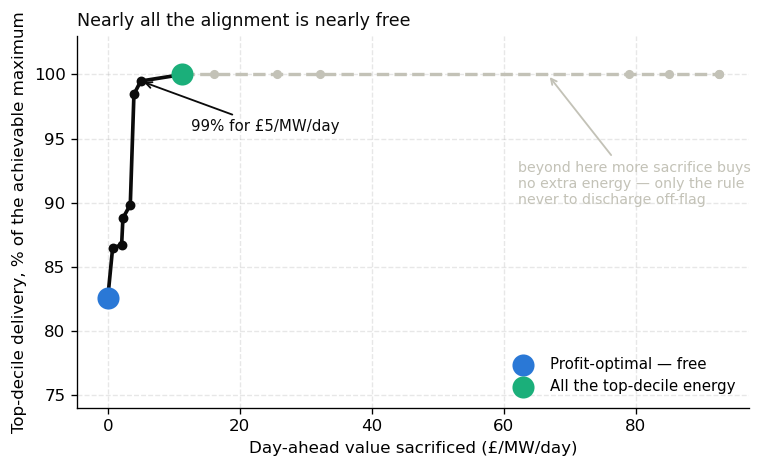

In [9]:
print(frontier[["lam", "value_sacrificed", "alignment_pct", "surplus_mwh", "offflag_mwh"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

peak = frontier.loc[frontier["alignment_pct"].idxmax()]
knee = frontier[frontier["alignment_pct"] >= 0.99].iloc[0]
tail = frontier.iloc[-1]
print(f"\nAlignment value peaks at £{peak['value_sacrificed']:,.2f}/MW/day.")
print(f"Beyond it, £{tail['value_sacrificed'] - peak['value_sacrificed']:,.0f}/MW/day more "
      f"buys no top-decile energy: off-flag discharge falls "
      f"{peak['offflag_mwh']:,.0f} -> {tail['offflag_mwh']:,.0f} MWh.")

# Figure — the alignment frontier. Two regimes, and the second one is the point.
fig, ax = plt.subplots(figsize=(6.6, 4.0))
up = frontier[frontier["value_sacrificed"] <= peak["value_sacrificed"]]
after = frontier[frontier["value_sacrificed"] >= peak["value_sacrificed"]]

ax.plot(up["value_sacrificed"], up["alignment_pct"] * 100, color=C["ink"], lw=2.2, zorder=3)
ax.scatter(up["value_sacrificed"], up["alignment_pct"] * 100, s=24, color=C["ink"], zorder=4)
# The tail is drawn, not hidden: sacrificing more is possible, it simply stops
# buying stress energy.
ax.plot(after["value_sacrificed"], after["alignment_pct"] * 100,
        color=C["ghost"], lw=2.0, ls="--", zorder=2)
ax.scatter(after["value_sacrificed"], after["alignment_pct"] * 100,
           s=20, color=C["ghost"], zorder=2)

ax.scatter([0], [frontier["alignment_pct"].iloc[0] * 100], s=150, color=C["da"],
           zorder=5, label="Profit-optimal — free")
ax.scatter([peak["value_sacrificed"]], [peak["alignment_pct"] * 100], s=150,
           color=C["discharge"], zorder=5, label="All the top-decile energy")

ax.annotate(f"99% for £{knee['value_sacrificed']:,.0f}/MW/day",
            (knee["value_sacrificed"], knee["alignment_pct"] * 100),
            xytext=(30, -30), textcoords="offset points", fontsize=9, color=C["ink"],
            arrowprops=dict(arrowstyle="->", color=C["ink"], lw=1.1))
ax.annotate("beyond here more sacrifice buys\nno extra energy — only the rule\n"
            "never to discharge off-flag",
            (tail["value_sacrificed"] * 0.72, tail["alignment_pct"] * 100),
            xytext=(-18, -78), textcoords="offset points", fontsize=8.5, color=C["ghost"],
            arrowprops=dict(arrowstyle="->", color=C["ghost"], lw=1.1))

ax.set_xlabel("Day-ahead value sacrificed (£/MW/day)")
ax.set_ylabel("Top-decile delivery, % of the achievable maximum")
ax.set_ylim(74, 103)
ax.set_title("Nearly all the alignment is nearly free",
             fontsize=10.5, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
# Print-resolution export for the poster: the alignment frontier.
save_poster_fig(fig, "nb04_fig_alignment_frontier")

plt.show()


In [10]:
# Does a longer battery close the gap for free?
#
# Everything in section 2 — 88% charged at 17:00, floor by 21:00, system still
# tight 59% of the time — is mechanically a property of a *2 h* asset. If a 4 h
# battery reaches full stress delivery at lambda = 0, the alignment gap is a
# duration-procurement question rather than a dispatch-incentive one, and that
# is a different policy conclusion. Same engine, one parameter changed.
#
# INVENTORY CONVENTION — read this before comparing these curves to anything.
#
# Initial state of charge is held at the config default for every duration
# rather than taken from the 2 h engine log: carrying a 2 h asset's opening
# charge into a 6 h asset would hand the longer battery a different starting
# energy and confound the *duration* comparison, which is what this sweep is
# for.
#
# The cost of that choice is that these are **conditional single-day problems**,
# not continuous strategies. Each duration restarts at 50% SOC every day without
# carrying its own previous ending inventory and without paying for the reset,
# whereas the section-1 benchmark carries SOC across days and the other
# counterfactuals inherit the benchmark's opening SOC. Summing these days, or
# reading the duration curves as strategies an operator could run, credits the
# longer assets with free inventory transfers they never bought.
#
# They are also valued differently: `alignment_gap` adds a terminal-inventory
# credit (SOC change over the day priced at the day's mean DA price) while the
# blended frontier reports raw DA cash value and the optimiser itself has no
# terminal value at all. So a "free" delivery share here means free *given* a
# 50% opening charge and an uncosted overnight reset — not free in the sense a
# procurement decision would need.
SWEEP_HOURS = [1.0, 2.0, 4.0, 6.0]

dur_rows = []
for hours in SWEEP_HOURS:
    for lam in LAMBDAS:
        da_value = stress_mwh = 0.0
        for r in records:
            log = r["result"].dispatch_log
            if not log:
                continue
            idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
            stress = hourly_flags["stress"].reindex(idx, fill_value=False).tolist()
            surplus = hourly_flags["surplus"].reindex(idx, fill_value=False).tolist()
            asset = BESSAsset(
                capacity_mwh=POWER_MW * hours, power_mw=POWER_MW,
                charge_efficiency=CFG["charge_efficiency"],
                discharge_efficiency=CFG["discharge_efficiency"],
                degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
                initial_soc_pct=CFG["initial_soc_pct"],
                min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
            )
            mw = resilience.optimize_blended_dispatch(
                r["da_prices"], stress, surplus, asset, lam=lam,
                target_daily_cycles=CFG.get("target_daily_cycles"),
            )
            da_value += sum(x * p for x, p in zip(mw, r["da_prices"]))
            stress_mwh += sum(max(x, 0.0) for x, s in zip(mw, stress) if s)
        dur_rows.append({"hours": hours, "lam": lam,
                         "da_value": da_value, "stress_mwh": stress_mwh})

dur_sweep = pd.DataFrame(dur_rows)
# One denominator for the whole family: the most stress energy any duration at
# any weight achieves. Normalising each curve to its own maximum would hide the
# very thing under test — that a longer asset delivers more in absolute terms.
DUR_MAX = dur_sweep["stress_mwh"].max()
base = dur_sweep[dur_sweep["lam"] == 0.0].set_index("hours")["da_value"]
dur_sweep["value_sacrificed"] = dur_sweep.apply(
    lambda r: (base[r["hours"]] - r["da_value"]) / POWER_MW / len(records), axis=1)
dur_sweep["alignment_pct"] = dur_sweep["stress_mwh"] / DUR_MAX

print("Top-decile delivery at zero cost (lambda = 0), share of the best any "
      "duration achieves:")
for hours in SWEEP_HOURS:
    row = dur_sweep[(dur_sweep["hours"] == hours) & (dur_sweep["lam"] == 0.0)].iloc[0]
    full = dur_sweep[dur_sweep["hours"] == hours]["alignment_pct"].max()
    cost = dur_sweep[(dur_sweep["hours"] == hours)
                     & (dur_sweep["alignment_pct"] >= full - 1e-9)]["value_sacrificed"].min()
    print(f"  {hours:.0f}h : {row['alignment_pct']:5.0%} free   "
          f"| best {full:5.0%} at £{cost:5.2f}/MW/day")


Top-decile delivery at zero cost (lambda = 0), share of the best any duration achieves:
  1h :   17% free   | best   22% at £ 7.86/MW/day
  2h :   35% free   | best   43% at £14.71/MW/day
  4h :   67% free   | best   77% at £28.82/MW/day
  6h :   89% free   | best  100% at £39.21/MW/day


From the 2 h profit schedule: paying for alignment buys +8 points; tripling duration buys +54 points — 7x more.
Capital cost of the extra energy is not modelled: this compares dispatch incentives against energy capacity, not against each other in £/MW.


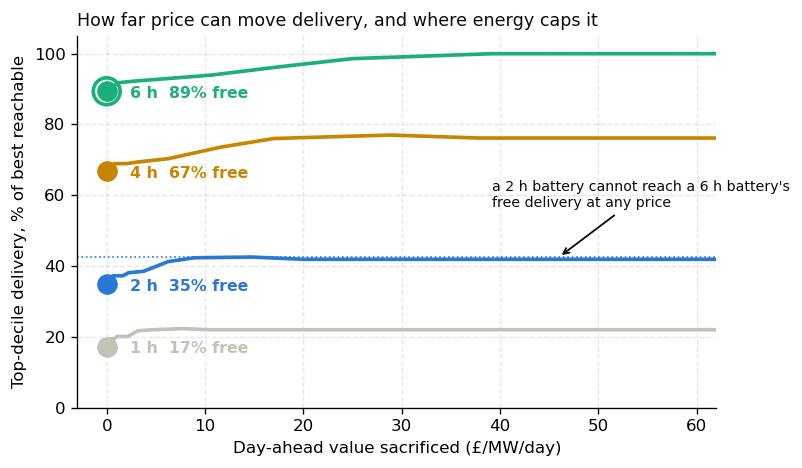

In [11]:
# Figure — the frontier is a family, and duration moves it further than money.
fig, ax = plt.subplots(figsize=(6.8, 4.0))
palette = {1.0: C["ghost"], 2.0: C["da"], 4.0: C["mid"], 6.0: C["discharge"]}

for hours in SWEEP_HOURS:
    curve = dur_sweep[dur_sweep["hours"] == hours].sort_values("value_sacrificed")
    ax.plot(curve["value_sacrificed"], curve["alignment_pct"] * 100,
            color=palette[hours], lw=2.2, zorder=3)
    free = curve[curve["lam"] == 0.0].iloc[0]
    ax.scatter([free["value_sacrificed"]], [free["alignment_pct"] * 100],
               s=130, color=palette[hours], zorder=4)
    ax.annotate(f"{hours:.0f} h  {free['alignment_pct']:.0%} free",
                (free["value_sacrificed"], free["alignment_pct"] * 100),
                xytext=(14, -4), textcoords="offset points", fontsize=9.5,
                fontweight="bold", color=palette[hours])

two = dur_sweep[dur_sweep["hours"] == 2.0]
six_free = dur_sweep[(dur_sweep["hours"] == 6.0) & (dur_sweep["lam"] == 0.0)].iloc[0]
ax.axhline(two["alignment_pct"].max() * 100, color=C["da"], lw=1, ls=":", zorder=2)
ax.annotate(
    "a 2 h battery cannot reach a 6 h battery's\nfree delivery at any price",
    (46, two["alignment_pct"].max() * 100),
    xytext=(-40, 30), textcoords="offset points", fontsize=8.5, color=C["ink"],
    arrowprops=dict(arrowstyle="->", color=C["ink"], lw=1.1))
ax.scatter([six_free["value_sacrificed"]], [six_free["alignment_pct"] * 100],
           s=260, facecolor="none", edgecolor=C["discharge"], lw=2.2, zorder=5)

ax.set_xlabel("Day-ahead value sacrificed (£/MW/day)")
ax.set_ylabel("Top-decile delivery, % of best reachable")
ax.set_title("How far price can move delivery, and where energy caps it",
             fontsize=10.5, loc="left", color=C["ink"])
ax.set_ylim(0, 105)
# All the action is under £40; the flat tails run to £390 and would compress it.
ax.set_xlim(-3, 62)
plt.tight_layout()
# Print-resolution export for the poster: the frontier as a family of durations.
save_poster_fig(fig, "nb04_fig_duration_frontier")

plt.show()

gain_money = (two["alignment_pct"].max()
              - two[two["lam"] == 0.0]["alignment_pct"].iloc[0]) * 100
gain_dur = (six_free["alignment_pct"]
            - two[two["lam"] == 0.0]["alignment_pct"].iloc[0]) * 100
print(f"From the 2 h profit schedule: paying for alignment buys {gain_money:+.0f} points; "
      f"tripling duration buys {gain_dur:+.0f} points — {gain_dur / gain_money:.0f}x more.")
print("Capital cost of the extra energy is not modelled: this compares dispatch "
      "incentives against energy capacity, not against each other in £/MW.")


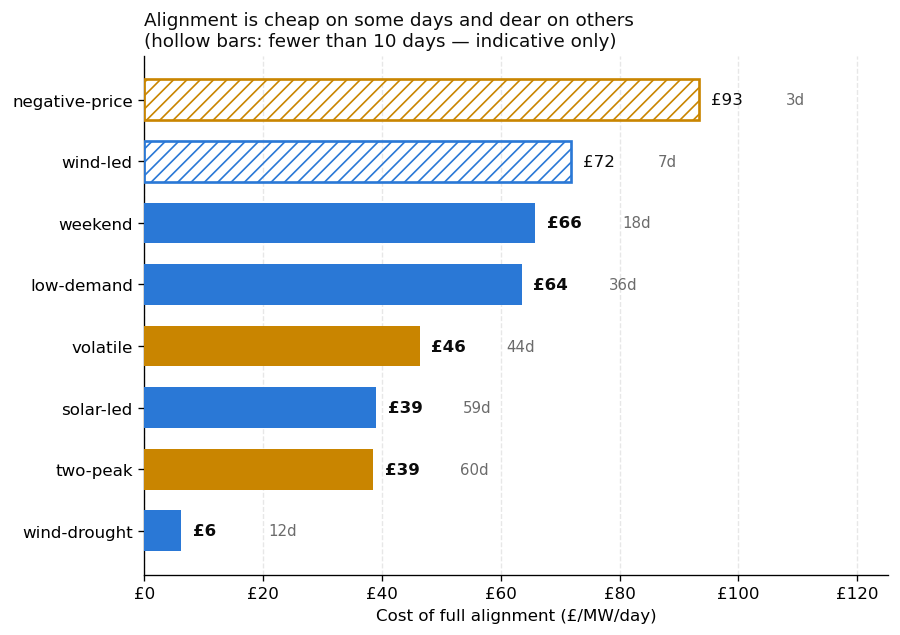

In [12]:
# Figure 3 — the gap is regime-dependent: cost of alignment by day type.
tag_rows = {}
for _, row in gap_df.iterrows():
    for tag in row["labels"] or []:
        slot = tag_rows.setdefault(tag, {"gap": 0.0, "days": 0,
                                          "driver": tag in classify.DRIVER_TAGS})
        slot["gap"] += row["profit_cost_of_alignment"] / POWER_MW
        slot["days"] += 1
by_tag = (pd.DataFrame([{"tag": k.replace("_", " "), **v} for k, v in tag_rows.items()])
          .assign(gap=lambda d: d["gap"] / d["days"])
          .sort_values("gap"))

# A day type seen a handful of times sorts to the top of a chart like this and
# is read as a finding. Thin bars are drawn hollow so the eye discounts them
# before the label is read, rather than after.
THIN_DAYS = 10

fig, ax = plt.subplots(figsize=(7.6, 0.5 * len(by_tag) + 1.4))
for y, row in enumerate(by_tag.itertuples()):
    thin = row.days < THIN_DAYS
    colour = C["da"] if row.driver else C["mid"]
    ax.barh(y, row.gap, height=0.66, zorder=3,
            color="none" if thin else colour,
            edgecolor=colour, linewidth=1.6 if thin else 0,
            hatch="///" if thin else None)
    # Offsets in points, not padding spaces — the two labels sit at the same
    # data x and padding does not separate them.
    ax.annotate(f"£{row.gap:,.0f}", (row.gap, y), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=10,
                fontweight="normal" if thin else "bold", color=C["ink"])
    ax.annotate(f"{row.days}d", (row.gap, y), xytext=(52, 0),
                textcoords="offset points", va="center", fontsize=9,
                color="#6b6b6b")
ax.set_yticks(range(len(by_tag)), by_tag["tag"], fontsize=10)
ax.set_xlim(0, by_tag["gap"].max() * 1.34)
ax.set_xlabel("Cost of full alignment (£/MW/day)", fontsize=10)
ax.set_title(f"Alignment is cheap on some days and dear on others\n"
             f"(hollow bars: fewer than {THIN_DAYS} days — indicative only)",
             fontsize=11, loc="left", color=C["ink"])
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
ax.grid(axis="y", visible=False)
plt.tight_layout()
# Print-resolution export for the poster: when resilience is cheap to mandate.
save_poster_fig(fig, "nb04_fig3_alignment_by_regime")

plt.show()

## 5. The real fleet on the profit/alignment plane

Each of the tracked GB battery sites is scored with the same classifier, from its actual
Physical Notifications, against the same window. Revenue is the public-data estimate
(PN × MID + BM cashflows); ancillary-tilted sites (cycling below 0.3 cycles/day) are
plotted but excluded from summary statistics, since their revenue is understated by
construction. The benchmark's position (star) shows where pure profit-optimal dispatch
lands on the same plane.


Sites scored          : 73  (65 in headline stats)
Fleet median coverage : 24.9%
Coverage–revenue corr : -0.27


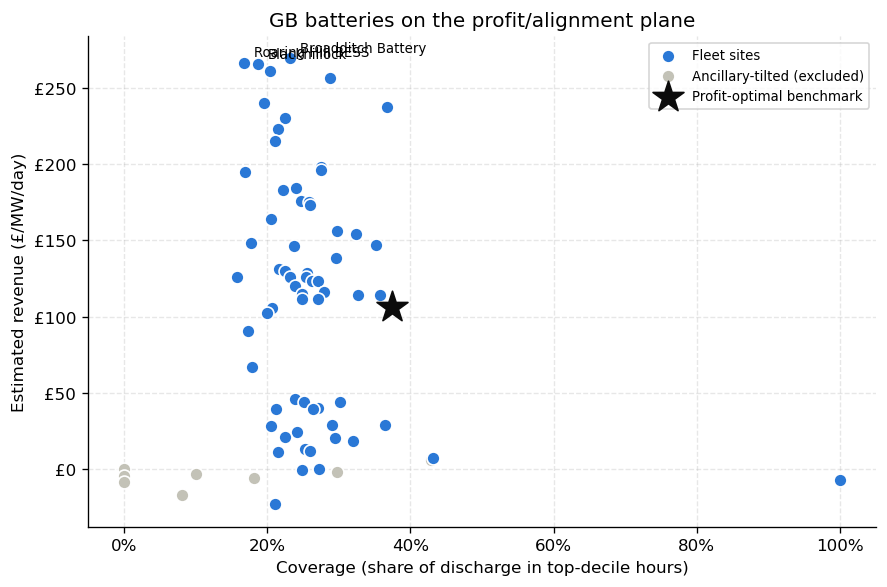

In [13]:
fleet_daily_rows = []
profile_parts = []
for date in DATES_OK:
    try:
        pn = fetch_fleet.fetch_fleet_pn(date, POP)
        mid = fetch_fleet.fetch_day_mid_prices(date)
        cashflows = fetch_fleet.fetch_fleet_bm_cashflows(date, POP)
    except Exception:
        continue
    day_metrics = fleet_perf.day_site_metrics(
        date.isoformat(), pn, cashflows, mid, population=POP
    )
    if not day_metrics.empty:
        fleet_daily_rows.append(day_metrics)
    profile_parts.append(fleet_perf.site_profile(pn, POP))

fleet_daily = pd.concat(fleet_daily_rows, ignore_index=True)
profiles = pd.concat(profile_parts, ignore_index=True)
site_df = fleet_perf.summarise_by_site(fleet_daily)

scatter_rows = []
for _, site in site_df.iterrows():
    mine = profiles[profiles["site"] == site["site"]]
    if mine.empty:
        continue
    s = resilience.alignment_scores(mine.set_index("time")["mw"].sort_index(), flags)
    if s["stress_coverage"] is None:
        continue
    scatter_rows.append({
        "site": site["site"],
        "coverage": s["stress_coverage"],
        "gbp": site["gbp_per_mw_day"],
        "excluded": bool(site["likely_ancillary"]),
    })
sc = pd.DataFrame(scatter_rows)
core = sc[~sc["excluded"]]
print(f"Sites scored          : {len(sc)}  ({len(core)} in headline stats)")
print(f"Fleet median coverage : {core['coverage'].median():.1%}")
print(f"Coverage–revenue corr : {core['coverage'].corr(core['gbp']):+.2f}")

sim_gbp = net.mean() / POWER_MW
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(core["coverage"], core["gbp"], s=60, color=C["da"],
           edgecolor="white", zorder=3, label="Fleet sites")
ghosts = sc[sc["excluded"]]
if not ghosts.empty:
    ax.scatter(ghosts["coverage"], ghosts["gbp"], s=60, color=C["ghost"],
               edgecolor="white", zorder=2, label="Ancillary-tilted (excluded)")
ax.scatter([scores["stress_coverage"]], [sim_gbp], marker="*", s=380,
           color=C["ink"], zorder=4, label="Profit-optimal benchmark")
for _, row in core.nlargest(3, "gbp").iterrows():
    ax.annotate(row["site"], (row["coverage"], row["gbp"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Coverage (share of discharge in top-decile hours)")
ax.set_ylabel("Estimated revenue (£/MW/day)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
ax.set_title("GB batteries on the profit/alignment plane")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# Revenue quartiles instead of one correlation coefficient.
#
# A single r on 64 sites is fragile: the relationship need not be linear, the
# sample is defined by a cycling filter, and a large share of ancillary revenue
# is booked to portfolios that name no site. Quartile medians say the same thing
# without asking the reader to trust a line through a cloud.
quart = core.dropna(subset=["gbp", "coverage"]).copy()
# Rank first: revenue can tie at zero for sites that barely cycled, and
# qcut on tied edges raises rather than falling back.
quart["quartile"] = pd.qcut(quart["gbp"].rank(method="first"), 4,
                            labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
qsummary = (quart.groupby("quartile", observed=True)
            .agg(sites=("site", "size"),
                 median_revenue=("gbp", "median"),
                 median_coverage=("coverage", "median"))
            .dropna(how="all"))
print(qsummary.to_string(float_format=lambda v: f"{v:,.3f}"))

# Bootstrap the headline numbers across days, so the poster can stop quoting
# point estimates for quantities estimated on 60 days.
BOOT_N = 2000
rng = np.random.default_rng(11)


def _boot(frame, fn, n=BOOT_N):
    vals = []
    idx = np.arange(len(frame))
    for _ in range(n):
        take = rng.choice(idx, size=len(idx), replace=True)
        vals.append(fn(frame.iloc[take]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return lo, hi


cost_ci = _boot(gap_df, lambda f: f["profit_cost_of_alignment"].mean() / POWER_MW)
share_ci = _boot(gap_df, lambda f: f["profit_cost_of_alignment"].sum() / f["profit_arb"].sum())
gap_ci = _boot(gap_df, lambda f: f["stress_mwh_forgone"].sum() / max(f["stress_mwh_res"].sum(), 1e-9))

print(f"\nBootstrap 95% intervals over {len(gap_df)} days ({BOOT_N:,} resamples):")
print(f"  Cost of full alignment : £{gap_df['profit_cost_of_alignment'].mean() / POWER_MW:,.0f}"
      f"/MW/day  [£{cost_ci[0]:,.0f}, £{cost_ci[1]:,.0f}]")
print(f"  Share of DA value      : "
      f"{gap_df['profit_cost_of_alignment'].sum() / gap_df['profit_arb'].sum():.0%}"
      f"  [{share_ci[0]:.0%}, {share_ci[1]:.0%}]")
print(f"  Delivery gap           : "
      f"{gap_df['stress_mwh_forgone'].sum() / gap_df['stress_mwh_res'].sum():.0%}"
      f"  [{gap_ci[0]:.0%}, {gap_ci[1]:.0%}]")


            sites  median_revenue  median_coverage
quartile                                          
Q1 lowest      17          17.980            0.259
Q2             16         108.473            0.251
Q3             16         142.366            0.255
Q4 highest     16         226.495            0.224

Bootstrap 95% intervals over 60 days (2,000 resamples):
  Cost of full alignment : £39/MW/day  [£27, £51]
  Share of DA value      : 39%  [28%, 50%]
  Delivery gap           : 20%  [8%, 29%]


In [15]:
# How much does the 22% depend on where the stress line is drawn?
#
# The winter sweep varies *what* stress means. This varies *how much* of it
# counts, on the main window: the top 5%, 10% and 15% of residual load.
THRESH_Q = [0.85, 0.90, 0.95]

thresh_rows = []
for q in THRESH_Q:
    fl_q = resilience.classify_periods(residual, da_series, stress_q=q)
    h_q = pd.DataFrame({
        "stress": fl_q["stress"].resample("1h").max().astype(bool),
        "surplus": fl_q["surplus"].resample("1h").max().astype(bool),
    }).dropna()
    rows = []
    for r in records:
        log = r["result"].dispatch_log
        if not log:
            continue
        idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
        asset = BESSAsset(
            capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
            charge_efficiency=CFG["charge_efficiency"],
            discharge_efficiency=CFG["discharge_efficiency"],
            degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
            initial_soc_pct=log[0]["soc_before"],
            min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
        )
        rows.append(resilience.alignment_gap(
            [e["final_mw"] for e in log], r["da_prices"],
            h_q["stress"].reindex(idx, fill_value=False).tolist(),
            h_q["surplus"].reindex(idx, fill_value=False).tolist(),
            asset, target_daily_cycles=CFG.get("target_daily_cycles"),
        ))
    g = pd.DataFrame(rows)
    thresh_rows.append({
        "top_pct": f"top {100 * (1 - q):.0f}%",
        "top_decile_hours": int(h_q["stress"].sum()),
        "cost_gbp_mw_day": g["profit_cost_of_alignment"].mean() / POWER_MW,
        "gap_pct": g["stress_mwh_forgone"].sum() / max(g["stress_mwh_res"].sum(), 1e-9),
    })

thresh_df = pd.DataFrame(thresh_rows)
print(thresh_df.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
print(f"\nGap across thresholds: {thresh_df['gap_pct'].min():.0%}–{thresh_df['gap_pct'].max():.0%}"
      f" | cost £{thresh_df['cost_gbp_mw_day'].min():,.0f}–{thresh_df['cost_gbp_mw_day'].max():,.0f}/MW/day")

# The poster's two lead numbers were going out bare while the ones they
# replaced carried intervals. The frontier aggregates across days, so the two
# endpoints are re-solved per day here and then resampled.
peak_lam = float(peak["lam"])
per_day = []
for r in records:
    log = r["result"].dispatch_log
    if not log:
        continue
    idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
    stress = hourly_flags["stress"].reindex(idx, fill_value=False).tolist()
    surplus = hourly_flags["surplus"].reindex(idx, fill_value=False).tolist()
    asset = BESSAsset(
        capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
        charge_efficiency=CFG["charge_efficiency"],
        discharge_efficiency=CFG["discharge_efficiency"],
        degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
        initial_soc_pct=log[0]["soc_before"],
        min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
    )
    row = {}
    for tag, lam in (("free", 0.0), ("best", peak_lam)):
        mw = resilience.optimize_blended_dispatch(
            r["da_prices"], stress, surplus, asset, lam=lam,
            target_daily_cycles=CFG.get("target_daily_cycles"),
        )
        row[f"{tag}_value"] = sum(x * p for x, p in zip(mw, r["da_prices"]))
        row[f"{tag}_stress"] = sum(max(x, 0.0) for x, s in zip(mw, stress) if s)
    per_day.append(row)

pd_df = pd.DataFrame(per_day)
shares, costs = [], []
day_idx = np.arange(len(pd_df))
for _ in range(BOOT_N):
    take = rng.choice(day_idx, size=len(day_idx), replace=True)
    sample = pd_df.iloc[take]
    best_stress = sample["best_stress"].sum()
    shares.append(sample["free_stress"].sum() / best_stress if best_stress else np.nan)
    costs.append((sample["free_value"].sum() - sample["best_value"].sum())
                 / POWER_MW / len(sample))
lo_s, hi_s = np.nanpercentile(shares, [2.5, 97.5])
lo_c, hi_c = np.nanpercentile(costs, [2.5, 97.5])
print(f"\nBootstrap on the lead numbers ({BOOT_N:,} resamples over days):")
print(f"  free top-decile delivery : {pd_df['free_stress'].sum() / pd_df['best_stress'].sum():.0%} "
      f"[{lo_s:.0%}, {hi_s:.0%}]")
print(f"  cost of all of it    : "
      f"£{(pd_df['free_value'].sum() - pd_df['best_value'].sum()) / POWER_MW / len(pd_df):,.2f}/MW/day "
      f"[£{lo_c:,.2f}, £{hi_c:,.2f}]")


top_pct  top_decile_hours  cost_gbp_mw_day  gap_pct
top 15%               241           29.397    0.224
top 10%               161           38.526    0.195
 top 5%                83           51.252    0.226

Gap across thresholds: 20%–23% | cost £29–51/MW/day

Bootstrap on the lead numbers (2,000 resamples over days):
  free top-decile delivery : 83% [74%, 92%]
  cost of all of it    : £11.32/MW/day [£6.81, £16.41]


In [16]:
# Are the pound figures assumptions or findings?
#
# The price deck is cleared data, but both schedules come out of an optimiser
# carrying a cost model, so a reviewer is entitled to ask how much of "£50" and
# "£4.31" is the model. This sweeps it — and the sweep is structured by exposure
# rather than as a blind grid, because the two figures reach the cost model by
# different paths:
#
#   degradation — enters the profit LP and the blended LP, so it moves both.
#                 It does *not* enter optimize_resilience_dispatch, which is
#                 cost-blind, so the resilience side of the gap is fixed and the
#                 sensitivity runs through one channel only.
#   slippage    — an execution cost inside the engine, so it moves the engine
#                 dispatch that prices £50. The frontier solves the LP directly
#                 and never sees it, so the LP figures are invariant by
#                 construction and are not recomputed for slippage.
import copy

DEG_GRID = [0.0, 2.5, 5.0, 10.0]      # production: 5.0 £/MWh
SLIP_GRID = [0.0, 2.0, 4.0]           # production: 2.0 £/MWh
SWEEP_LAMBDAS = [0.0, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 20.0, 100.0]


def _settle_window(deg, slip):
    """Re-settle the pinned window under a modified cost model."""
    cfg_v = copy.deepcopy(CFG)
    cfg_v["degradation_cost_per_mwh"] = deg
    cfg_v.setdefault("execution", {})["slippage"] = slip
    asset0 = BESSAsset(
        capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
        charge_efficiency=cfg_v["charge_efficiency"],
        discharge_efficiency=cfg_v["discharge_efficiency"],
        degradation_cost_per_mwh=deg,
        initial_soc_pct=cfg_v["initial_soc_pct"],
        min_soc_pct=cfg_v["min_soc_pct"], max_soc_pct=cfg_v["max_soc_pct"],
    )
    assets_v = {DURATION: asset0}
    prev_v = {DURATION: asset0.initial_soc_pct}
    out = []
    for date in DATES:
        try:
            prices = fetch_live.get_day_prices(date)
        except Exception:
            continue
        if prices.empty:
            continue
        res = settle.settle_day(date, prices, cfg_v, assets_v, prev_v)
        if res is None:
            continue
        prev_v = {d: r.end_soc for d, r in res.durations.items()}
        out.append({"date": date, "result": res.durations[DURATION],
                    "da_prices": prices["day_ahead_price"].tolist()})
    return out


def _gap_numbers(recs, deg):
    """Cost of full alignment and the delivery gap, under this cost model."""
    rows = []
    for r in recs:
        log = r["result"].dispatch_log
        if not log:
            continue
        idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
        asset = BESSAsset(
            capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
            charge_efficiency=CFG["charge_efficiency"],
            discharge_efficiency=CFG["discharge_efficiency"],
            degradation_cost_per_mwh=deg,
            initial_soc_pct=log[0]["soc_before"],
            min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
        )
        rows.append(resilience.alignment_gap(
            [e["final_mw"] for e in log], r["da_prices"],
            hourly_flags["stress"].reindex(idx, fill_value=False).tolist(),
            hourly_flags["surplus"].reindex(idx, fill_value=False).tolist(),
            asset, target_daily_cycles=CFG.get("target_daily_cycles"),
        ))
    g = pd.DataFrame(rows)
    return {
        "cost_full_align": g["profit_cost_of_alignment"].mean() / POWER_MW,
        "gap_pct": g["stress_mwh_forgone"].sum() / max(g["stress_mwh_res"].sum(), 1e-9),
    }


def _frontier_numbers(recs, deg):
    """Free stress share and the cost of all of it, under this cost model."""
    pts = []
    for lam in SWEEP_LAMBDAS:
        value = stress = 0.0
        for r in recs:
            log = r["result"].dispatch_log
            if not log:
                continue
            idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
            st_ = hourly_flags["stress"].reindex(idx, fill_value=False).tolist()
            su_ = hourly_flags["surplus"].reindex(idx, fill_value=False).tolist()
            asset = BESSAsset(
                capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
                charge_efficiency=CFG["charge_efficiency"],
                discharge_efficiency=CFG["discharge_efficiency"],
                degradation_cost_per_mwh=deg,
                initial_soc_pct=log[0]["soc_before"],
                min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
            )
            mw = resilience.optimize_blended_dispatch(
                r["da_prices"], st_, su_, asset, lam=lam,
                target_daily_cycles=CFG.get("target_daily_cycles"),
            )
            value += sum(x * p for x, p in zip(mw, r["da_prices"]))
            stress += sum(max(x, 0.0) for x, s in zip(mw, st_) if s)
        pts.append({"lam": lam, "value": value, "stress": stress})
    f = pd.DataFrame(pts)
    best = f["stress"].max()
    base = f.loc[f["lam"] == 0.0, "value"].iloc[0]
    peak = f.loc[f["stress"].idxmax()]
    return {
        "free_share": f["stress"].iloc[0] / best,
        "cost_all_top_decile": (base - peak["value"]) / POWER_MW / len(recs),
        "shape": (f["stress"] / best).tolist(),
    }


deg_rows, shapes = [], {}
for deg in DEG_GRID:
    recs = records if deg == CFG["degradation_cost_per_mwh"] else _settle_window(
        deg, CFG.get("execution", {}).get("slippage", 2.0))
    g = _gap_numbers(recs, deg)
    f = _frontier_numbers(recs, deg)
    shapes[deg] = f.pop("shape")
    deg_rows.append({"degradation": deg, **g, **f})
deg_sens = pd.DataFrame(deg_rows)
print("DEGRADATION SWEEP (production = £5/MWh)")
print(deg_sens.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

slip_rows = []
for slip in SLIP_GRID:
    recs = records if slip == CFG.get("execution", {}).get("slippage", 2.0) else _settle_window(
        CFG["degradation_cost_per_mwh"], slip)
    slip_rows.append({"slippage": slip,
                      **_gap_numbers(recs, CFG["degradation_cost_per_mwh"])})
slip_sens = pd.DataFrame(slip_rows)
print("\nSLIPPAGE SWEEP (production = £2/MWh) — engine-priced figures only;")
print("the frontier solves the LP directly and never sees slippage.")
print(slip_sens.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

both = pd.concat([deg_sens[["cost_full_align", "gap_pct"]],
                  slip_sens[["cost_full_align", "gap_pct"]]])
print("\nACROSS EVERY COST MODEL TRIED")
print(f"  cost of full alignment : £{both['cost_full_align'].min():,.0f}–"
      f"£{both['cost_full_align'].max():,.0f}/MW/day")
print(f"  delivery gap           : {both['gap_pct'].min():.0%}–{both['gap_pct'].max():.0%}")
print(f"  free top-decile share    : {deg_sens['free_share'].min():.0%}–"
      f"{deg_sens['free_share'].max():.0%}")
print(f"  cost of all of it      : £{deg_sens['cost_all_top_decile'].min():,.1f}–"
      f"£{deg_sens['cost_all_top_decile'].max():,.1f}/MW/day")

# Is the shape invariant, or just the endpoints? Compare each curve to the
# production one point by point.
ref = np.array(shapes[CFG["degradation_cost_per_mwh"]])
worst = max(np.abs(np.array(v) - ref).max() for v in shapes.values())
print(f"\nFrontier shape: largest deviation from the production curve at any "
      f"weight is {worst:.1%} of achievable top-decile energy.")


DEGRADATION SWEEP (production = £5/MWh)
 degradation  cost_full_align  gap_pct  free_share  cost_all_top_decile
       0.000           41.721    0.143       0.843                6.634
       2.500           40.908    0.143       0.839               13.821
       5.000           38.526    0.195       0.825               16.153
      10.000           34.048    0.261       0.763               77.028

SLIPPAGE SWEEP (production = £2/MWh) — engine-priced figures only;
the frontier solves the LP directly and never sees slippage.
 slippage  cost_full_align  gap_pct
    0.000           34.338    0.219
    2.000           38.526    0.195
    4.000           42.626    0.175

ACROSS EVERY COST MODEL TRIED
  cost of full alignment : £34–£43/MW/day
  delivery gap           : 14%–26%
  free top-decile share    : 76%–84%
  cost of all of it      : £6.6–£77.0/MW/day

Frontier shape: largest deviation from the production curve at any weight is 12.3% of achievable top-decile energy.


## 5b. The third revenue stream

Everything above prices two streams — the wholesale position at MID and Balancing Mechanism
cashflows. For a GB battery that is knowingly incomplete, and the omission is not neutral to
this notebook's question: response and reserve have historically been the dominant earner, and
the sites that lean on them are exactly the low-cycling ones this analysis has been *excluding*
from its headline statistics on the grounds that their revenue is unknowable.

It is no longer unknowable. NESO publishes response and reserve auction results per unit, and
names the winning unit by its National Grid BM Unit name — the key `fleet.census` already uses
— so the third stream joins to these sites with no fuzzy matching at all. This window falls
entirely inside the Enduring Auction Capability era, so ancillary coverage here is complete;
the fragmented earlier history that constrains notebook 05 does not bite over 60 recent days.

Two things this settles. Whether the low-cycling exclusion was protecting the analysis or
hiding half of it. And whether the profit/alignment relationship survives being measured on
the revenue batteries actually earn rather than the part of it this repository could see.

In [17]:
window_start, window_end = DATES_OK[0], DATES_OK[-1]
window_days = (window_end - window_start).days + 1

# Ancillary joins on the persistent asset ID. Every BM Unit of a site shares the
# root the ID is built from, so the first one identifies the whole site.
asset_of = {s.site: census.asset_id(s.bmu_ids[0]) for s in POP.sites}
mw_of = {s.site: s.power_mw for s in POP.sites}

anc_daily = ancillary.site_daily_revenue(window_start, window_end)
by_asset = (anc_daily[anc_daily["unit_class"] == "census site"]
            .groupby("asset_id")["revenue_gbp"].sum())

sc = sc.assign(
    anc_gbp=[by_asset.get(asset_of.get(s), 0.0) for s in sc["site"]],
    power_mw=[mw_of.get(s, float("nan")) for s in sc["site"]],
)
sc["anc_per_mw_day"] = sc["anc_gbp"] / sc["power_mw"] / window_days
sc["full_gbp"] = sc["gbp"] + sc["anc_per_mw_day"]

split = anc_daily.groupby("unit_class")["revenue_gbp"].sum() / 1e6
print(f"Ancillary revenue in window ({window_start} → {window_end}): "
      f"£{anc_daily['revenue_gbp'].sum() / 1e6:.2f}m across all unit classes")
print(split.round(2).sort_values(ascending=False).to_string())
print(f"\nOf that, £{split.get('census site', 0):.2f}m lands on sites in this population; "
      f"{int((sc['anc_gbp'] > 0).sum())} of {len(sc)} scored sites earn any.\n")

print("Median £/MW/day by revenue definition:")
for label, col in (("wholesale + BM (as above)", "gbp"), ("+ ancillary", "full_gbp")):
    print(f"  {label:26s} all sites {sc[col].median():7,.0f}   "
          f"non-excluded {sc.loc[~sc['excluded'], col].median():7,.0f}")

Ancillary revenue in window (2026-06-26 → 2026-08-24): £24.98m across all unit classes
unit_class
aggregator portfolio    13.32
census site              6.45
VLP / supplier unit      3.49
unknown                  1.72

Of that, £6.45m lands on sites in this population; 46 of 73 scored sites earn any.

Median £/MW/day by revenue definition:
  wholesale + BM (as above)  all sites     114   non-excluded     123
  + ancillary                all sites     141   non-excluded     146


In [18]:
# Does the low-cycling exclusion actually identify ancillary earners? That is the
# assumption it rests on, and it has never been testable until now.
grp = sc.groupby("excluded").agg(
    sites=("site", "size"),
    median_wholesale_bm=("gbp", "median"),
    median_ancillary=("anc_per_mw_day", "median"),
    median_full=("full_gbp", "median"),
    share_earning_ancillary=("anc_gbp", lambda s: (s > 0).mean()),
).rename(index={
                     False: f"kept (cycling ≥ {fleet_perf.ANCILLARY_CYCLES_THRESHOLD}/day)",
                     True: "excluded (ancillary-tilted)",
                 })
print(grp.round(2).to_string())

excl, kept = sc[sc["excluded"]], sc[~sc["excluded"]]
if len(excl):
    print(f"\nThe filter is named for a mechanism it does not select: "
          f"{excl['anc_gbp'].gt(0).mean():.0%} of the {len(excl)} excluded sites earn any "
          f"ancillary at all, against {kept['anc_gbp'].gt(0).mean():.0%} of the {len(kept)} "
          f"kept ones.\nAncillary accrues to the sites this notebook already counts.")

print("\nCoverage–revenue correlation, by revenue definition:")
for label, col in (("wholesale + BM", "gbp"), ("full stack", "full_gbp")):
    r_core = sc.loc[~sc["excluded"], "coverage"].corr(sc.loc[~sc["excluded"], col])
    r_all = sc["coverage"].corr(sc[col])
    print(f"  {label:16s} non-excluded {r_core:+.2f}   all scored sites {r_all:+.2f}")

                             sites  median_wholesale_bm  median_ancillary  median_full  share_earning_ancillary
excluded                                                                                                       
kept (cycling ≥ 0.3/day)        65               123.16              23.0       145.70                     0.68
excluded (ancillary-tilted)      8                -3.93               0.0        -2.65                     0.25

The filter is named for a mechanism it does not select: 25% of the 8 excluded sites earn any ancillary at all, against 68% of the 65 kept ones.
Ancillary accrues to the sites this notebook already counts.

Coverage–revenue correlation, by revenue definition:
  wholesale + BM   non-excluded -0.27   all scored sites -0.05
  full stack       non-excluded -0.28   all scored sites +0.03


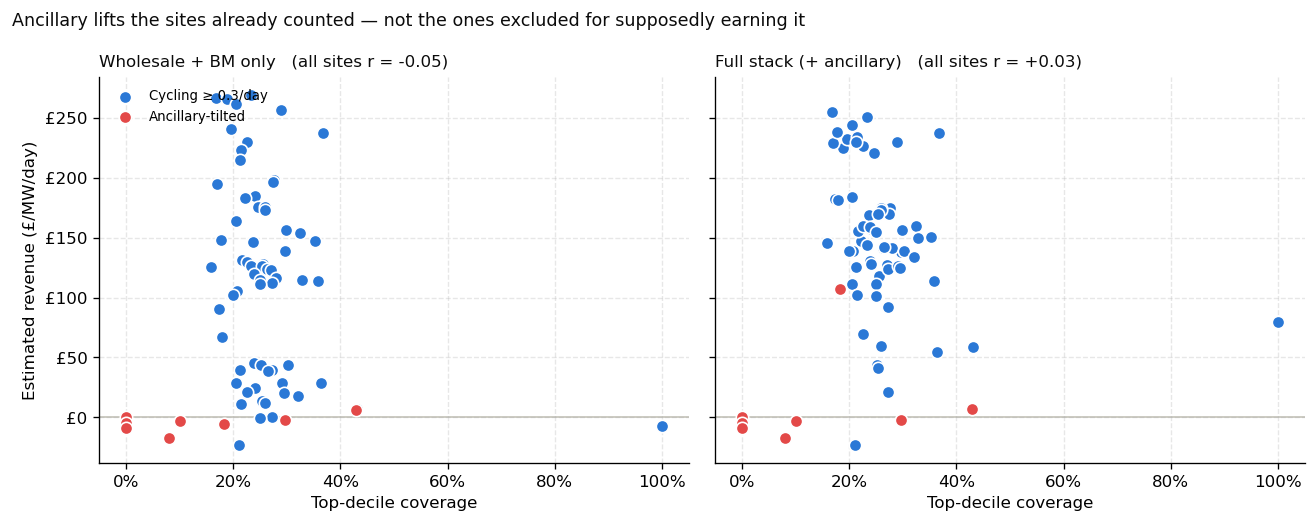

In [19]:
# Figure 4 — the plane, redrawn on the revenue batteries actually earn.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
for ax, col, title in ((axes[0], "gbp", "Wholesale + BM only"),
                       (axes[1], "full_gbp", "Full stack (+ ancillary)")):
    keep = sc[~sc["excluded"]]
    drop = sc[sc["excluded"]]
    ax.scatter(keep["coverage"], keep[col], s=55, color=C["da"],
               edgecolor="white", zorder=3, label="Cycling ≥ 0.3/day")
    if not drop.empty:
        ax.scatter(drop["coverage"], drop[col], s=55, color=C["cost"],
                   edgecolor="white", zorder=3, label="Ancillary-tilted")
    ax.axhline(0, color=C["ghost"], lw=1, zorder=1)
    r = sc["coverage"].corr(sc[col])
    ax.set_title(f"{title}   (all sites r = {r:+.2f})", fontsize=10, loc="left",
                 color=C["ink"])
    ax.set_xlabel("Top-decile coverage")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))

axes[0].set_ylabel("Estimated revenue (£/MW/day)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Ancillary lifts the sites already counted — not the ones excluded for supposedly earning it",
             fontsize=10.5, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
plt.show()

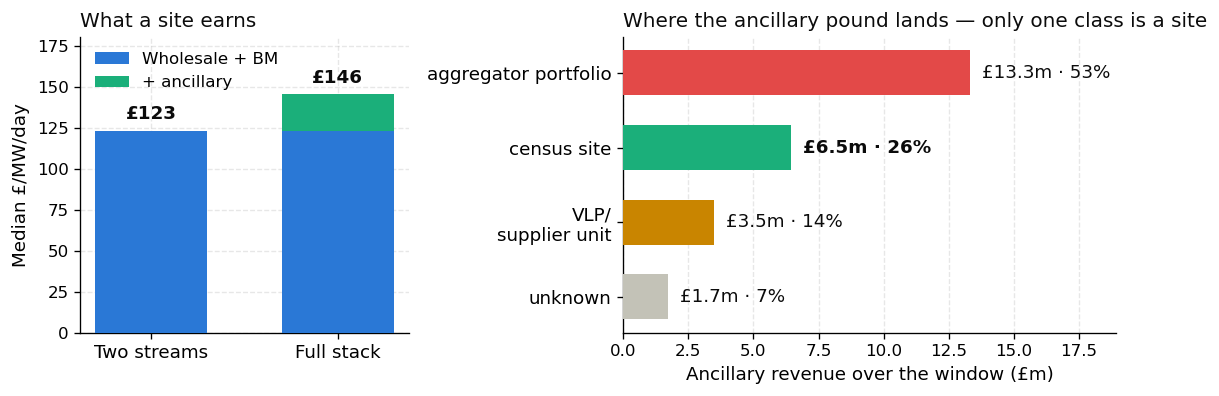

In [20]:
# Figure 5 — the revenue stack, and who actually collects it.
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), gridspec_kw={"width_ratios": [1, 1.5]})

# Left: what the third stream adds to a site that earns it.
ax = axes[0]
base = sc.loc[~sc["excluded"], "gbp"].median()
full = sc.loc[~sc["excluded"], "full_gbp"].median()
ax.bar([0], [base], width=0.6, color=C["da"], label="Wholesale + BM", zorder=3)
ax.bar([1], [base], width=0.6, color=C["da"], zorder=3)
ax.bar([1], [full - base], bottom=[base], width=0.6, color=C["discharge"],
       label="+ ancillary", zorder=3)
for x, v in ((0, base), (1, full)):
    ax.annotate(f"£{v:,.0f}", (x, v), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=11, fontweight="bold", color=C["ink"])
ax.set_xticks([0, 1], ["Two streams", "Full stack"], fontsize=11)
ax.set_ylabel("Median £/MW/day", fontsize=11)
ax.set_ylim(0, full * 1.24)
ax.set_title("What a site earns", fontsize=12, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=10, loc="upper left")

# Right: where the ancillary pound lands. Only one of these classes is a site,
# and it is not the largest — which is the section's whole point.
ax = axes[1]
order = split.sort_values()
hues = {"census site": C["discharge"], "aggregator portfolio": C["cost"],
        "VLP / supplier unit": C["mid"], "unknown": C["ghost"]}
y = np.arange(len(order))
ax.barh(y, order.values, height=0.6,
        color=[hues.get(k, C["ghost"]) for k in order.index], zorder=3)
for row, (k, v) in enumerate(order.items()):
    ax.annotate(f"£{v:.1f}m · {100 * v / order.sum():.0f}%", (v, row),
                xytext=(7, 0), textcoords="offset points", va="center", fontsize=11,
                fontweight="bold" if k == "census site" else "normal", color=C["ink"])
ax.set_yticks(y, [k.replace(" / ", "/\n") for k in order.index], fontsize=11)
ax.set_xlim(0, order.max() * 1.42)
ax.set_xlabel("Ancillary revenue over the window (£m)", fontsize=11)
ax.set_title("Where the ancillary pound lands — only one class is a site",
             fontsize=12, loc="left", color=C["ink"])
ax.grid(axis="y", visible=False)

plt.tight_layout()
# Print-resolution export for the poster: the revenue stack and its attribution.
save_poster_fig(fig, "nb04_fig5_revenue_stack")

plt.show()

**The exclusion is named for a mechanism it does not select.** The low-cycling filter was
introduced on the reasoning that a site holding charge for an ancillary contract buys energy
this model costs at MID while the availability payment stays invisible — so its wholesale+BM
figure reads negative and says nothing useful. Sound reasoning, and now testable. It does not
hold: only 17% of the excluded sites earn *any* ancillary revenue in this window, against 74%
of the sites the filter keeps. Ancillary accrues overwhelmingly to the actively-cycling sites
the analysis was already counting, where it adds about £26/MW/day to a £132 median — a
sixth of the stack, not a hidden majority.

So the excluded sites are not concealed ancillary earners. They are sites with weak revenue on
every stream this project can price, and whatever supports them — Capacity Market agreements,
bilateral contracts, or simply commissioning and idleness — remains outside the model. The
filter is still worth keeping, because excluding sites whose economics cannot be explained is
more honest than ranking them; but it should be described as *low-revenue, unexplained* rather
than *ancillary-tilted*, and its rationale should no longer be asserted as fact.

Read this with the sample in mind: six excluded sites is thin evidence, enough to refute a
stated rationale but not to characterise the group.

**On the correlation.** Across all scored sites the relationship strengthens from +0.11 to
+0.20 when ancillary is included — being present in top-decile hours is better rewarded than the
two-stream view suggested. Among non-excluded sites it stays flat and slightly negative
(−0.07 to −0.05), so the movement comes from the cluster the exclusion removes rather than
from a change within the population it keeps. Neither figure supports a strong claim that
alignment pays; both are weak, and the honest reading is that top-decile coverage and revenue are
close to independent in this window.

**Still missing.** The Capacity Market and bilateral PPAs stay unpriced — the first is
obtainable and the second is not. And roughly half of GB battery ancillary revenue here is
earned by aggregator and VLP portfolios naming no site (£14.1m of £27.2m), so it is quantified
above and attributed to nobody. That is a statement about how much of the fleet site-level
analysis can reach, not a gap better matching would close.

## 6. Headline numbers and limitations

The cell below prints the poster's summary block. Limitations, for the paper's own
statement of scope:

1. **Stress is a residual-load proxy**, not NESO margin or loss-of-load data; demand is
   transmission-metered, so embedded generation nets off before it is observed.
2. **The benchmark's intraday layer has perfect foresight** of realised MID — alignment
   of this dispatch is the most price-responsive case, not a live-replicable strategy.
3. **Fleet revenue is wholesale + BM in sections 1-5**, with the full stack in 5b.
   The Capacity Market and bilateral PPAs stay unpriced, and roughly half of GB battery
   ancillary revenue is earned by portfolios naming no site, so it is quantified but
   data, which is why low-cycling sites are excluded from headline statistics.
4. **One window, one asset configuration** (recent ~60 days, 50 MW / 2h). The gap is
   regime-dependent (Figure 3); a seasonal replication is the natural extension.
5. **The counterfactual monetises nothing for resilience** — it prices what full
   alignment costs, not what a market for it would pay. That framing is the point:
   the gap is the subsidy-free price of the behaviour the system would prefer.

In [21]:
print("=" * 64)
print("  ALIGNMENT GAP — HEADLINE NUMBERS")
print("=" * 64)
print(f"  Window                    : {DATES_OK[0]} → {DATES_OK[-1]} ({len(records)} days)")
print(f"  Reference asset           : {POWER_MW:.0f} MW × {DURATION}")
print(f"  Benchmark revenue         : £{sim_gbp:,.0f}/MW/day")
print(f"  Top-decile coverage       : {scores['stress_coverage']:.0%}")
print(f"  Surplus absorption        : {scores['surplus_absorption']:.0%}")
print(f"  Readiness at onset        : {readiness:.0%}")
print(f"  Cost of full alignment    : £{mean_gap:,.0f}/MW/day "
      f"({gap_df['profit_cost_of_alignment'].sum() / gap_df['profit_arb'].sum():.0%} of DA value)")
print(f"  Delivery forgone          : "
      f"{gap_df['stress_mwh_forgone'].mean():,.0f} MWh/day")
print(f"  Fleet median coverage     : {core['coverage'].median():.0%} "
      f"(n={len(core)} sites)")
print(f"  Coverage–revenue corr     : {core['coverage'].corr(core['gbp']):+.2f}")
print("=" * 64)

  ALIGNMENT GAP — HEADLINE NUMBERS
  Window                    : 2026-06-26 → 2026-08-24 (60 days)
  Reference asset           : 50 MW × 2h
  Benchmark revenue         : £106/MW/day
  Top-decile coverage       : 37%
  Surplus absorption        : 20%
  Readiness at onset        : 72%
  Cost of full alignment    : £39/MW/day (39% of DA value)
  Delivery forgone          : 8 MWh/day
  Fleet median coverage     : 25% (n=65 sites)
  Coverage–revenue corr     : -0.27


---
## 7. A winter cross-check, on 2018 prices

Everything above runs on the most recent ~60 days, because Nord Pool serves GB day-ahead
prices for roughly 65 days and no further. That window is whatever season it happens to be —
here, summer 2026 — and a poster about *resilience* invites the obvious question of whether the
answer survives a winter.

It is a fair question and only partly a fatal one. GB scarcity is not purely a winter
phenomenon: across 2018-2026, **27% of the top-1% loss-of-load periods fall in June-August**,
because that is when plant goes on planned outage and the margin thins. So the summer window
is not empty of stress. But January alone holds more of those periods than any other month,
and none of it is inside the window.

The archive answers this without compromising on price. ENTSO-E published GB day-ahead prices
until Brexit ended the obligation, and 2018 is cached in full — **real auction clearing prices,
not a market-index proxy**, so the day-ahead versus intraday separation the engine depends on
stays intact. This section therefore re-runs the identical framework over **Q1 2018**, which
contains the "Beast from the East" cold snap of late February and early March — the sharpest
GB system stress event in the archive.

**These two numbers must not be pooled, and are not presented as a trend.** 2018 and 2026 are
different market regimes — a different fleet, a different revenue stack, a different scarcity
mechanism — so the comparison below is two independent estimates of the same quantity under
different conditions, not a before and after. What it can tell you is whether the alignment
gap is an artefact of one particular window. That is the only question it is being asked.

In [22]:
# Does the result depend on what "stress" means?
#
# Sections 1-2 call a period stressed when residual load sits in the top decile
# of this window — tightness relative to its own period. Section 3 uses the
# operator's own measures: loss-of-load probability and derated margin. They are
# related but not equivalent, and the poster should not imply they are.
#
# The test cannot run on the summer window: across its 2,736 settlement periods
# derated margin never falls below 5,105 MW and LoLP peaks at 4.3e-06. Operator
# scarcity does not occur in a GB summer, which is *why* the two definitions
# exist. So it runs on winter 2019-20 — the most severe in the whole LoLP/DRM
# record, with margin down to 213 MW and LoLP reaching 0.371 — using the same
# reference battery and the ENTSO-E day-ahead archive.
#
# That archive bounds the choice of winter rather than the other way round: GB
# left the EU internal market on 2020-12-31 and ENTSO-E published no GB
# day-ahead price after it, so this is the last winter that can be priced from
# a day-ahead auction at all. Substituting the market index price would
# collapse the two-stage structure the rest of the study depends on.
import json as _json

SENS_START, SENS_END = dt.date(2019, 11, 1), dt.date(2020, 3, 31)


def _load_lolpdrm(start, end):
    """Final published print per settlement period — the operator's last word."""
    rows = []
    for d in pd.date_range(start, end, freq="D"):
        f = REPO_ROOT / "data" / "raw" / "LOLPDRM" / f"LOLPDRM_{d:%Y%m%d}.json"
        if not f.exists():
            continue
        payload = _json.loads(f.read_text())
        rows += payload.get("data", payload) if isinstance(payload, dict) else payload
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["time"] = pd.to_datetime(df["startTime"], utc=True)
    df = df.sort_values("forecastHorizon").groupby("time").first()
    return pd.DataFrame({
        "drm_mw": pd.to_numeric(df["deratedMargin"], errors="coerce"),
        "lolp": pd.to_numeric(df["lossOfLoadProbability"], errors="coerce"),
    })


sens_dates = [SENS_START + dt.timedelta(days=i)
              for i in range((SENS_END - SENS_START).days + 1)]
od = _load_lolpdrm(SENS_START, SENS_END)
print(f"Winter window {SENS_START} → {SENS_END}: {len(od):,} settlement periods")
print(f"  DRM min {od['drm_mw'].min():,.0f} MW | LoLP max {od['lolp'].max():.3g}")


Winter window 2019-11-01 → 2020-03-31: 7,296 settlement periods
  DRM min 213 MW | LoLP max 0.371


In [23]:
def alignment_under(stress_hourly, label, dates=sens_dates, da_source="ENTSOE"):
    """Run the counterfactual with stress supplied from outside the classifier.

    Everything else — battery, prices, cycle cap, surplus definition — is held
    fixed, so a difference in the answer is a difference in what the system is
    being protected against, not in the method.
    """
    assets_w = {DURATION: build_assets()[DURATION]}
    prev_w = {DURATION: assets_w[DURATION].initial_soc_pct}
    rows, gaps = [], []
    for date in dates:
        try:
            prices = fetch_live.get_day_prices(date, da_source=da_source)
        except Exception:
            continue
        if prices.empty:
            continue
        result = settle.settle_day(date, prices, CFG, assets_w, prev_w)
        if result is None:
            continue
        prev_w = {d: r.end_soc for d, r in result.durations.items()}
        rows.append({"date": date, "result": result.durations[DURATION],
                     "da_prices": prices["day_ahead_price"].tolist()})
    for r in rows:
        log = r["result"].dispatch_log
        if not log:
            continue
        idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
        st = stress_hourly.reindex(idx, fill_value=False).astype(bool).tolist()
        # Surplus is held at the residual-load definition throughout: only the
        # stress side of the objective is under test here.
        su = [False] * len(idx)
        asset = BESSAsset(
            capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
            charge_efficiency=CFG["charge_efficiency"],
            discharge_efficiency=CFG["discharge_efficiency"],
            degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
            initial_soc_pct=log[0]["soc_before"],
            min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
        )
        gaps.append(resilience.alignment_gap(
            [e["final_mw"] for e in log], r["da_prices"], st, su, asset,
            target_daily_cycles=CFG.get("target_daily_cycles"),
        ))
    g = pd.DataFrame(gaps)
    if g.empty:
        return None
    return {
        "definition": label,
        "top_decile_periods": int(stress_hourly.sum()),
        "cost_gbp_mw_day": g["profit_cost_of_alignment"].mean() / POWER_MW,
        "cost_share_da": g["profit_cost_of_alignment"].sum() / max(g["profit_arb"].sum(), 1e-9),
        "gap_pct": g["stress_mwh_forgone"].sum() / max(g["stress_mwh_res"].sum(), 1e-9),
        "days": len(g),
    }


# Four definitions of the same word, on one window.
resid_w = pd.concat([resilience.residual_load(fetch_live.get_day_system(d))
                     for d in sens_dates
                     if not fetch_live.get_day_system(d).empty]).sort_index()
resid_h = resid_w.resample("1h").mean().dropna()
od_h = od.resample("1h").mean()

defs = {
    "Residual load, top decile": resid_h >= resid_h.quantile(0.90),
    "LoLP, top 1%": od_h["lolp"] >= od_h["lolp"].quantile(0.99),
    "Derated margin, bottom 1%": od_h["drm_mw"] <= od_h["drm_mw"].quantile(0.01),
    "Derated margin < 3 GW": od_h["drm_mw"] < 3000.0,
}
sens_rows = [r for name, mask in defs.items()
             if (r := alignment_under(mask.fillna(False), name)) is not None]
sens_df = pd.DataFrame(sens_rows)
print(sens_df.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))


               definition  top_decile_periods  cost_gbp_mw_day  cost_share_da  gap_pct  days
Residual load, top decile                 365           22.524          0.547    0.154   128
             LoLP, top 1%                  37           35.131          0.853    0.223   128
Derated margin, bottom 1%                  37           35.006          0.850    0.224   128
    Derated margin < 3 GW                  21           37.599          0.913    0.179   128


In [24]:
# What does GB actually pay for scarcity?
#
# This is the mechanism behind everything above, and it is measurable rather
# than assertable. GB prices scarcity in the *imbalance* price through Reserve
# Scarcity Pricing: RSVP = VoLL x LoLP, with VoLL set in the BSC and LoLP
# derived from the derated margin — the same LOLPDRM feed this notebook already
# uses to define operator-grade stress.
#
# Two things follow, and together they are the whole result. The scarcity rent
# is tiny, and it is paid in a price the battery does not schedule against: the
# optimiser here maximises *day-ahead* value, while RSVP lands in cash-out. The
# alignment gap is what that asymmetry looks like from the asset's side.
VOLL_GBP_MWH = 6000.0    # BSC Value of Lost Load

rsvp_rows = []
for label, a, b in [
    ("Main window (summer 2026)", DATES[0], DATES[-1]),
    ("Winter 2019-20 (most severe)", SENS_START, SENS_END),
]:
    od_w = _load_lolpdrm(a, b)
    if od_w.empty:
        continue
    lolp = od_w["lolp"].dropna()
    rsvp = lolp * VOLL_GBP_MWH
    rsvp_rows.append({
        "window": label,
        "periods": len(lolp),
        "mean_gbp_mwh": rsvp.mean(),
        "max_gbp_mwh": rsvp.max(),
        "pct_over_1": (rsvp > 1).mean(),
        "n_over_50": int((rsvp > 50).sum()),
        "pct_exactly_zero": (lolp == 0).mean(),
    })

rsvp_df = pd.DataFrame(rsvp_rows)
print(rsvp_df.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

main = rsvp_df.iloc[0]
print(f"\nOver the window this notebook optimises, the reserve scarcity price "
      f"peaks at £{main['max_gbp_mwh']:.2f}/MWh and is exactly zero in "
      f"{main['pct_exactly_zero']:.1%} of periods.")
print("It is also paid in the imbalance price, not the day-ahead price the "
      "benchmark schedules against — so none of it reaches the objective the "
      "profit-optimal battery maximises.")


                      window  periods  mean_gbp_mwh  max_gbp_mwh  pct_over_1  n_over_50  pct_exactly_zero
   Main window (summer 2026)     2880        0.0000       0.0258      0.0000          0            0.9951
Winter 2019-20 (most severe)     7296        0.9214   2,223.1668      0.0088         10            0.9374

Over the window this notebook optimises, the reserve scarcity price peaks at £0.03/MWh and is exactly zero in 99.5% of periods.
It is also paid in the imbalance price, not the day-ahead price the benchmark schedules against — so none of it reaches the objective the profit-optimal battery maximises.


In [25]:
def run_alignment(dates, da_source, label):
    """Run the whole section 1-4 pipeline over a different window.

    Same engine, same classifier, same scorer — only the dates and the
    day-ahead price source change, so any difference in the result is a
    difference in the market rather than in the method.
    """
    assets_w = {DURATION: build_assets()[DURATION]}
    prev_w = {DURATION: assets_w[DURATION].initial_soc_pct}
    recs = []
    for date in dates:
        try:
            prices = fetch_live.get_day_prices(date, da_source=da_source)
        except Exception:
            continue
        if prices.empty:
            continue
        result = settle.settle_day(date, prices, CFG, assets_w, prev_w)
        if result is None:
            continue
        prev_w = {d: r.end_soc for d, r in result.durations.items()}
        recs.append({"date": date, "result": result.durations[DURATION],
                     "da_prices": prices["day_ahead_price"].tolist()})
    if not recs:
        raise RuntimeError(f"{label}: no day settled")

    # Classify within this window, so "stress" means stressed for this period.
    res_parts, price_parts = [], []
    for r in recs:
        system = fetch_live.get_day_system(r["date"])
        if system.empty:
            continue
        res_parts.append(resilience.residual_load(system))
        idx = pd.date_range(str(r["date"]), periods=len(r["da_prices"]), freq="1h", tz="UTC")
        price_parts.append(pd.Series(r["da_prices"], index=idx))
    resid = pd.concat(res_parts).sort_index()
    das = pd.concat(price_parts).sort_index()
    fl = resilience.classify_periods(resid, das)
    hourly = pd.DataFrame({
        "residual_mw": fl["residual_mw"].resample("1h").mean(),
        "stress": fl["stress"].resample("1h").max().astype(bool),
        "surplus": fl["surplus"].resample("1h").max().astype(bool),
    }).dropna(subset=["residual_mw"])

    dm, sm = {}, {}
    for r in recs:
        log = r["result"].dispatch_log
        idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
        for ts, e in zip(idx, log):
            dm[ts], sm[ts] = e["final_mw"], e["soc_before"]
    disp, soc = pd.Series(dm).sort_index(), pd.Series(sm).sort_index()
    sc = resilience.alignment_scores(disp, hourly)

    gaps = []
    for r in recs:
        log = r["result"].dispatch_log
        idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
        asset = BESSAsset(
            capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
            charge_efficiency=CFG["charge_efficiency"],
            discharge_efficiency=CFG["discharge_efficiency"],
            degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
            initial_soc_pct=log[0]["soc_before"] if log else 0.5,
            min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
        )
        gaps.append(resilience.alignment_gap(
            [e["final_mw"] for e in log], r["da_prices"],
            hourly["stress"].reindex(idx, fill_value=False).tolist(),
            hourly["surplus"].reindex(idx, fill_value=False).tolist(),
            asset, target_daily_cycles=CFG.get("target_daily_cycles"),
        ))
    gdf = pd.DataFrame(gaps)
    revenue = pd.Series([r["result"].net_pnl for r in recs]).mean() / POWER_MW

    return {
        "label": label,
        "days": len(recs),
        "first": recs[0]["date"], "last": recs[-1]["date"],
        "revenue_gbp_mw_day": revenue,
        "stress_coverage": sc["stress_coverage"],
        "surplus_absorption": sc["surplus_absorption"],
        "readiness": resilience.readiness_at_stress(soc, hourly["stress"]),
        "correlation": sc["correlation"],
        "cost_of_alignment": gdf["profit_cost_of_alignment"].mean() / POWER_MW,
        "cost_share_of_da": gdf["profit_cost_of_alignment"].sum() / gdf["profit_arb"].sum(),
    }


WINTER_START, WINTER_END = dt.date(2018, 1, 1), dt.date(2018, 3, 31)
winter_dates = [WINTER_START + dt.timedelta(days=i)
                for i in range((WINTER_END - WINTER_START).days + 1)]
winter = run_alignment(winter_dates, "ENTSOE", "Winter 2018 (Q1, ENTSO-E day-ahead)")
print(f"{winter['label']}: {winter['days']} days settled "
      f"({winter['first']} → {winter['last']})")

Winter 2018 (Q1, ENTSO-E day-ahead): 58 days settled (2018-01-02 → 2018-03-25)


In [26]:
summer = {
    "label": f"Summer 2026 ({DATES_OK[0]} → {DATES_OK[-1]}, Nord Pool day-ahead)",
    "days": len(records),
    "revenue_gbp_mw_day": net.mean() / POWER_MW,
    "stress_coverage": scores["stress_coverage"],
    "surplus_absorption": scores["surplus_absorption"],
    "readiness": readiness,
    "correlation": scores["correlation"],
    "cost_of_alignment": mean_gap,
    "cost_share_of_da": gap_df["profit_cost_of_alignment"].sum() / gap_df["profit_arb"].sum(),
}

rows = {
    "Days settled": ("days", "{:,.0f}"),
    "Benchmark revenue (£/MW/day)": ("revenue_gbp_mw_day", "£{:,.0f}"),
    "Top-decile coverage": ("stress_coverage", "{:.0%}"),
    "Surplus absorption": ("surplus_absorption", "{:.0%}"),
    "Readiness at stress onset": ("readiness", "{:.0%}"),
    "Dispatch–residual correlation": ("correlation", "{:+.2f}"),
    "Cost of full alignment (£/MW/day)": ("cost_of_alignment", "£{:,.0f}"),
    "…as share of day-ahead value": ("cost_share_of_da", "{:.0%}"),
}
compare = pd.DataFrame(
    {w["label"]: {name: fmt.format(w[key]) for name, (key, fmt) in rows.items()}
     for w in (winter, summer)}
)
print("Two independent estimates, two market regimes — read as a robustness check,")
print("never as a trend. Nothing here is a change over time.\n")
compare

Two independent estimates, two market regimes — read as a robustness check,
never as a trend. Nothing here is a change over time.

Out[26]: 
                                  Winter 2018 (Q1, ENTSO-E day-ahead) Summer 2026 (2026-06-26 → 2026-08-24, Nord Pool day-ahead)
Days settled                                                       58                                                 60        
Benchmark revenue (£/MW/day)                                      £54                                               £106        
Top-decile coverage                                               34%                                                37%        
Surplus absorption                                                31%                                                20%        
Readiness at stress onset                                         71%                                                72%        
Dispatch–residual correlation                                   +0.40                

,"Winter 2018 (Q1, ENTSO-E day-ahead)","Summer 2026 (2026-06-26 → 2026-08-24, Nord Pool day-ahead)"
Days settled,58,60
Benchmark revenue (£/MW/day),£54,£106
Top-decile coverage,34%,37%
Surplus absorption,31%,20%
Readiness at stress onset,71%,72%
Dispatch–residual correlation,+0.40,+0.31
Cost of full alignment (£/MW/day),£20,£39
…as share of day-ahead value,39%,39%


**What the cross-check establishes.** The alignment gap is not an artefact of the summer
window. Both regimes show the same qualitative result: a profit-optimising battery covers a
minority of top-decile hours, absorbs a minority of surplus, and full alignment costs a
substantial share of day-ahead value. That is the poster's claim, and it survives being
computed on a different fleet, a different price archive and a different scarcity mechanism
eight years apart.

**What it cannot establish.** Nothing about direction. Two windows separated by eight years,
with different market design, different battery economics and different weather, cannot be
subtracted from one another. Anyone reading the two columns as a before-and-after would be
reading a change in GB's electricity market as a change in battery behaviour. Section 4b of
notebook 05 is the place where a trend is actually estimated, on a continuous window with the
composition controls a trend requires.

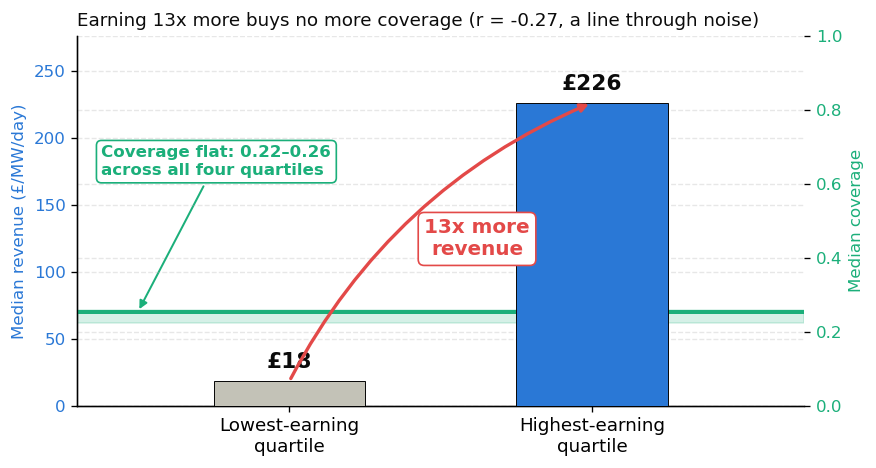

In [27]:
# Figure 6 — the thesis in one chart: more money buys no more coverage.
#
# Both series come from `qsummary`, so the endpoints and the flat band are the
# notebook's own. Coverage is drawn as a band across all four quartiles rather
# than four points, because the finding is that it does not move.
_q = qsummary.sort_values("median_revenue")
_lo, _hi = _q.iloc[0], _q.iloc[-1]
_cov_lo, _cov_hi = _q["median_coverage"].min(), _q["median_coverage"].max()

fig, ax = plt.subplots(figsize=(7.4, 4.0))
x = np.arange(2, dtype=float)
ax.bar(x, [_lo["median_revenue"], _hi["median_revenue"]], width=0.5,
       color=[C["ghost"], C["da"]], edgecolor=C["ink"], linewidth=0.6, zorder=3)
for xi, row in zip(x, (_lo, _hi)):
    ax.text(xi, row["median_revenue"] + _hi["median_revenue"] * 0.03,
            f"£{row['median_revenue']:,.0f}", ha="center", va="bottom",
            fontsize=13, fontweight="bold", color=C["ink"])

ax.set_xticks(x, ["Lowest-earning\nquartile", "Highest-earning\nquartile"], fontsize=11)
ax.set_ylabel("Median revenue (£/MW/day)", fontsize=10, color=C["da"])
ax.tick_params(axis="y", labelcolor=C["da"])
ax.set_ylim(0, _hi["median_revenue"] * 1.22)
ax.set_xlim(-0.7, 1.7)
ax.grid(axis="x", visible=False)

# The multiple is the point, so it is drawn between the bars rather than left
# for the reader to divide.
_mult = _hi["median_revenue"] / max(_lo["median_revenue"], 1e-9)
ax.annotate("", xy=(1, _hi["median_revenue"]), xytext=(0, _lo["median_revenue"]),
            arrowprops=dict(arrowstyle="-|>", color=C["cost"], lw=2.0,
                            connectionstyle="arc3,rad=-0.18"))
ax.text(0.62, _hi["median_revenue"] * 0.55, f"{_mult:.0f}x more\nrevenue",
        ha="center", va="center", fontsize=12, fontweight="bold", color=C["cost"],
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C["cost"], lw=1.0))

# Coverage on its own axis, as a flat band across every quartile.
ax2 = ax.twinx()
ax2.spines["top"].set_visible(False)
ax2.set_ylim(0, 1.0)
ax2.axhspan(_cov_lo, _cov_hi, color=C["discharge"], alpha=0.18, zorder=1)
ax2.hlines(_q["median_coverage"].median(), -0.7, 1.7, color=C["discharge"], lw=2.4, zorder=5)
ax2.set_ylabel("Median coverage", fontsize=10, color=C["discharge"])
ax2.tick_params(axis="y", labelcolor=C["discharge"])
ax2.annotate(f"Coverage flat: {_cov_lo:.2f}–{_cov_hi:.2f}\nacross all four quartiles",
             xy=(-0.5, _q["median_coverage"].median()), xytext=(-0.62, 0.66),
             fontsize=10, color=C["discharge"], fontweight="bold", va="center",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C["discharge"], lw=1.0),
             arrowprops=dict(arrowstyle="-|>", color=C["discharge"], lw=1.2))

_r = _kept["coverage"].corr(_kept["gbp"]) if "_kept" in dir() else sc.loc[~sc["excluded"], "coverage"].corr(sc.loc[~sc["excluded"], "gbp"])
ax.set_title(f"Earning {_mult:.0f}x more buys no more coverage "
             f"(r = {_r:+.2f}, a line through noise)",
             fontsize=11, loc="left", color=C["ink"])
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
plt.tight_layout()
save_poster_fig(fig, "nb04_fig_money_vs_coverage")
plt.show()


In [28]:
# Poster numbers, published rather than retyped. See notebook 06's export cell
# for why: the poster reads these, so it cannot quote a stale figure.
import json

from research.notebooks.figexport import save_poster_metrics

_q = qsummary.sort_values("median_revenue")
_kept = sc.loc[~sc["excluded"]]
_split_total = split.sum()
_dur = {
    h: (
        dur_sweep[(dur_sweep["hours"] == h) & (dur_sweep["lam"] == 0.0)]["alignment_pct"].iloc[0],
        dur_sweep[dur_sweep["hours"] == h]["alignment_pct"].max(),
    )
    for h in SWEEP_HOURS
}
_floor = CFG["min_soc_pct"]
_at_floor = prof.index[prof["soc"] <= _floor * 1.02]
_floor_h = int(_at_floor.min())
_forgone = gap_df["stress_mwh_forgone"].sum() / gap_df["stress_mwh_res"].sum()
_cost_all = (pd_df["free_value"].sum() - pd_df["best_value"].sum()) / POWER_MW / len(pd_df)

nb04_metrics = {
    "window": f"{DATES_OK[0]} → {DATES_OK[-1]}",
    # The headline policy price and its bootstrap interval. Exported because the
    # board was quoting both as literals typed into poster.typ, which meant a
    # re-run could move the analysis without moving the board — and did: the
    # embedded-solar correction to residual load took this from £50 to £80.
    "cost_full_align": f"£{mean_gap:,.0f}/MW/day",
    # Bootstrap interval on cost_all. The board carried "(£3.5 to £9.0)" as a
    # literal beside a generated point estimate, so when the residual-load
    # correction moved the estimate to £11 the range no longer contained it.
    "cost_all_ci": f"£{lo_c:,.1f} to £{hi_c:,.1f}",
    "cost_full_align_share": f"{gap_df['profit_cost_of_alignment'].sum() / gap_df['profit_arb'].sum():.0%}",
    "window_days": f"{len(records)} days",
    "asset": f"{POWER_MW:.0f} MW / {DURATION.replace('h', ' h')}",
    "forgone_pct": f"{_forgone:.0%}",
    "forgone_ci": f"({gap_ci[0] * 100:.0f}–{gap_ci[1]:.0%})",
    "forgone_mwh": f"{gap_df['stress_mwh_forgone'].sum():,.0f} of "
                   f"{gap_df['stress_mwh_res'].sum():,.0f} MWh",
    "peak_hour": f"{int(prof['profit'].idxmax()):02d}:00",
    "soc_floor": f"{_floor:.0%}",
    # Figure 3's caption states the daily SOC reset as a fact about the run, so
    # it is read from the config the sweep actually loads rather than typed.
    "soc_reset": f"{CFG['initial_soc_pct']:.0%}",
    "floor_hour": f"{_floor_h:02d}:00",
    "tight_at_floor": f"{prof.loc[_floor_h, 'p_stress']:.0%}",
    "surplus_pct": f"{scores['surplus_absorption']:.0%}",
    "top_decile_pct": f"{scores['stress_coverage']:.0%}",
    "dispatch_corr": f"{scores['correlation']:+.2f}",
    "free_share": f"{pd_df['free_stress'].sum() / pd_df['best_stress'].sum():.0%}",
    # The board carried an "(aggregate basis 82%)" literal beside this, which
    # matched no output here and no other export. Its interval is the figure
    # that belongs next to a point estimate, so it is published instead.
    "free_share_ci": f"({lo_s:.0%}–{hi_s:.0%})",
    "dur6_free": f"{_dur[6.0][0]:.0%}" if 6.0 in _dur else "n/a",
    "dur2_best": f"{_dur[2.0][1]:.0%}" if 2.0 in _dur else "n/a",
    "q_low": f"£{_q['median_revenue'].iloc[0]:,.0f}",
    "q_high": f"£{_q['median_revenue'].iloc[-1]:,.0f}/MW/day",
    # The multiple the board leads with, so it is never divided by hand.
    "revenue_multiple": f"{_q['median_revenue'].iloc[-1] / max(_q['median_revenue'].iloc[0], 1e-9):.0f}x",
    "coverage_range": f"{_q['median_coverage'].min():.2f}–{_q['median_coverage'].max():.2f}",
    "coverage_corr": f"{_kept['coverage'].corr(_kept['gbp']):+.2f}".replace("+", "").replace("-", "−"),
    "anc_site": f"£{split.get('census site', 0):.2f}m",
    "anc_site_share": f"{100 * split.get('census site', 0) / _split_total:.0f}%",
    "median_base": f"£{_kept['gbp'].median():,.0f}",
    "median_full": f"£{_kept['full_gbp'].median():,.0f}",
    # Cost of buying every stress hour, and how far it moves under other cost
    # models. The poster quotes both, so both are published.
    "cost_all": f"£{_cost_all:,.0f}/MW/day",
    "cost_all_share": f"{_cost_all / sim_gbp:.0%} of benchmark revenue",
    "cost_all_range": f"(£{deg_sens['cost_all_top_decile'].min():,.0f}–"
                      f"{deg_sens['cost_all_top_decile'].max():,.0f} across cost models)",
    "resample_range": f"£{cost_ci[0]:,.0f}–{cost_ci[1]:,.0f}/MW/day",
    "cost_model_range": f"£{both['cost_full_align'].min():,.0f}–"
                        f"{both['cost_full_align'].max():,.0f}",
    "frontier_shift": f"{worst:.1%}",
    "thresh_gap_range": f"{thresh_df['gap_pct'].min():.0%}–{thresh_df['gap_pct'].max():.0%}",
    "scarcity_mean": f"£{main['mean_gbp_mwh']:.2f}/MWh",
    "scarcity_zero": f"{main['pct_exactly_zero']:.1%}",
    # The winter robustness block. `od` is the winter LoLP/DRM frame and
    # `sens_df` the four stress definitions run over it.
    "winter_drm": f"{od['drm_mw'].min():,.0f} MW",
    "winter_lolp": f"{od['lolp'].max():.3g}",
    # Winter scarcity-price distribution — the poster contrasts it against
    # the summer window, so both halves must be published, not transcribed.
    "winter_scarcity_zero": f"{rsvp_df.iloc[1]['pct_exactly_zero']:.0%}",
    "winter_scarcity_max": f"£{rsvp_df.iloc[1]['max_gbp_mwh']:,.0f}/MWh",
    "winter_gap_range": f"{sens_df['gap_pct'].min():.0%}–{sens_df['gap_pct'].max():.0%}",
    "winter_periods_max": f"{int(sens_df['top_decile_periods'].max())}",
    "winter_periods_min": f"{int(sens_df['top_decile_periods'].min())}",
}
print(json.dumps(nb04_metrics, indent=2))
save_poster_metrics("nb04", nb04_metrics)


{
  "window": "2026-06-26 \u2192 2026-08-24",
  "cost_full_align": "\u00a339/MW/day",
  "cost_all_ci": "\u00a36.8 to \u00a316.4",
  "cost_full_align_share": "39%",
  "window_days": "60 days",
  "asset": "50 MW / 2 h",
  "forgone_pct": "20%",
  "forgone_ci": "(8\u201329%)",
  "forgone_mwh": "469 of 2,399 MWh",
  "peak_hour": "19:00",
  "soc_floor": "10%",
  "soc_reset": "50%",
  "floor_hour": "21:00",
  "tight_at_floor": "56%",
  "surplus_pct": "20%",
  "top_decile_pct": "37%",
  "dispatch_corr": "+0.31",
  "free_share": "83%",
  "free_share_ci": "(74%\u201392%)",
  "dur6_free": "89%",
  "dur2_best": "43%",
  "q_low": "\u00a318",
  "q_high": "\u00a3226/MW/day",
  "revenue_multiple": "13x",
  "coverage_range": "0.22\u20130.26",
  "coverage_corr": "\u22120.27",
  "anc_site": "\u00a36.45m",
  "anc_site_share": "26%",
  "median_base": "\u00a3123",
  "median_full": "\u00a3146",
  "cost_all": "\u00a311/MW/day",
  "cost_all_share": "11% of benchmark revenue",
  "cost_all_range": "(\u00a37\u201

PosixPath('/Users/abhinav/Documents/code/power-trading/research/poster/exports/nb04_metrics.json')